# 모델 비교와 활용 결정

현재 NN을 유지하고 LR을 기준 모델, 수정한 희소 NN을 후속 후보로 둔다. 두 비교 단계의 학습 조건이 다르므로 단계 내 비교를 우선한다. 원자료 없이 저장된 집계를 다시 표시한다.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [2]:
DATA=json.loads('{"first_comparison": {"plan": {"purpose": "Choose a practical model, not establish methodological novelty", "features": "Same 19 noninvasive variables; train-fitted imputation/encoding. LR_linear excludes engineered hinge/sex-body columns; all others share existing basis preprocessor.", "cohort": "4068 ages19-39, original strict unaware cohort", "roles": "Original PSU-separated train1680 validation372 calibration481 threshold529 test1006", "seeds": [42, 43, 44], "trials_per_family": 2, "max_epochs": 160, "patience": 20, "selection": "Mean validation four-label macro AP across three seeds; lower macro Brier tie break. Choose configuration and overall family before 2024 evaluation.", "calibration": "One joint-distribution temperature fitted on calibration role using joint NLL; report raw and calibrated metrics", "threshold": "Per-label weighted F1 on fixed .01:.01:.99 grid, plus any-abnormality sensitivity95, using threshold role only", "neural_loss": "weighted joint NLL/4 + .2 mean marginal BCE; same loss for all six neural candidates, AdamW lr .003, wd .001 or .01, 12 hidden units except existing 4-per-group grouped structures", "neural_initialization": "Unaries from train-only four LR(C=.1); pair energy initialized zero; no external teachers or API keys", "trees": "Four independently trained binary estimators, shared hyperparameter choice; 120 trees RF; 120 boosting iterations HGB", "test_use": "Previously inspected 2024; exploratory comparison, not independent confirmatory validation", "uncertainty": "300 full-frame stratified PSU resamples of test, paired seed-mean metric differences; fixed trained/calibrated models/thresholds, conditional intervals, no selection uncertainty", "speed": "CPU one thread; interleaved warmed single-person model inference including calibration and marginal aggregation; excludes input preprocessing/loading/HTTP; preprocessing timed separately", "adaptation": "Phase, sparse state update, coupled relaxation ideas reimplemented for static rows. No biological connectome, physical simulation, temporal health trajectory or original-weight transfer.", "no_promotion": true}, "cohort_flow": {"2021": {"all": 7090, "age_19_39": 1414, "known_diagnosis_status": 1321, "no_prior_diagnosis": 1269, "no_medication": 1269, "not_recorded_pregnant": 1258, "fasting": 1061, "complete_target": 1039, "valid_survey_design": 1039}, "2022": {"all": 6265, "age_19_39": 1284, "known_diagnosis_status": 1284, "no_prior_diagnosis": 1229, "no_medication": 1229, "not_recorded_pregnant": 1212, "fasting": 1035, "complete_target": 1013, "valid_survey_design": 1013}, "2023": {"all": 6929, "age_19_39": 1290, "known_diagnosis_status": 1290, "no_prior_diagnosis": 1237, "no_medication": 1237, "not_recorded_pregnant": 1220, "fasting": 1027, "complete_target": 1010, "valid_survey_design": 1010}, "2024": {"all": 6997, "age_19_39": 1353, "known_diagnosis_status": 1353, "no_prior_diagnosis": 1280, "no_medication": 1280, "not_recorded_pregnant": 1267, "fasting": 1011, "complete_target": 1006, "valid_survey_design": 1006}}, "validation_winner": "phase_pair", "models": {"LR_linear": {"seeds": [{"seed": 42, "fit_seconds": 0.014692299999296665, "temperature": 0.9186959683439584, "cuts": [0.27, 0.12, 0.25, 0.17], "screen_cut": 0.15227201586440808, "artifact_bytes": 4036, "parameters": 228, "tree_nodes": null, "raw": {"macro_ap": 0.3852568490088783, "macro_auc": 0.7986485739967908, "macro_brier": 0.10233557240476929, "micro_ap": 0.385177453802338, "macro_f1": 0.43738450031223136, "hamming_loss": 0.23327376115212414, "subset_accuracy": 0.45907241454206377, "joint_argmax_accuracy": 0.6308726222874295, "joint_nll": 1.3386335534800053, "any_auc": 0.8368852432014897, "count_mae": 0.5325330086503983, "per_label": {"0": {"ap": 0.38521561537868154, "auc": 0.8167328433336278, "brier": 0.08336468522728867}, "1": {"ap": 0.35858514678713393, "auc": 0.7907129759750888, "brier": 0.08762656146139368}, "2": {"ap": 0.48539615079598536, "auc": 0.8172267500107975, "brier": 0.1262297803716911}, "3": {"ap": 0.31183048307371247, "auc": 0.7699217266676486, "brier": 0.11212126255870372}}}, "calibrated": {"macro_ap": 0.3852568490088783, "macro_auc": 0.7986485739967908, "macro_brier": 0.10247847393293202, "micro_ap": 0.385177453802338, "macro_f1": 0.44000142347871785, "hamming_loss": 0.2118064390625327, "subset_accuracy": 0.49452670325610204, "joint_argmax_accuracy": 0.6308726222874295, "joint_nll": 1.3354129414526787, "any_auc": 0.8369513233967835, "count_mae": 0.5137343221501133, "per_label": {"0": {"ap": 0.38521561537868154, "auc": 0.8167328433336278, "brier": 0.08259110154441598}, "1": {"ap": 0.35858514678713393, "auc": 0.7907129759750888, "brier": 0.08800855535803788}, "2": {"ap": 0.48539615079598536, "auc": 0.8172267500107975, "brier": 0.12720980335194879}, "3": {"ap": 0.31183048307371247, "auc": 0.7699217266676486, "brier": 0.11210443547732543}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.15227201586440808, "prevalence": 0.3661402510524164, "sensitivity": 0.9646817950645199, "specificity": 0.22972499113295375, "ppv": 0.4197595452550564, "npv": 0.9184368517512983, "miss_rate_among_positive": 0.03531820493548007, "referral_rate": 0.8414551583716827, "referrals_per_1000": 841.4551583716827, "detected_per_1000": 353.20883463061904, "missed_per_1000": 12.931416421797362, "unnecessary_referrals_per_1000": 488.2463237410637, "tests_per_detected": 2.3823162839391183, "roc_auc": 0.8369513233967835, "average_precision": 0.7534594819956001, "brier": 0.15648041672793267, "unweighted_confusion": {"tn": 175, "fp": 488, "fn": 15, "tp": 328}}}, {"seed": 43, "fit_seconds": 0.011691100000462029, "temperature": 0.9186959683439584, "cuts": [0.27, 0.12, 0.25, 0.17], "screen_cut": 0.15227201586440808, "artifact_bytes": 4036, "parameters": 228, "tree_nodes": null, "raw": {"macro_ap": 0.3852568490088783, "macro_auc": 0.7986485739967908, "macro_brier": 0.10233557240476929, "micro_ap": 0.385177453802338, "macro_f1": 0.43738450031223136, "hamming_loss": 0.23327376115212414, "subset_accuracy": 0.45907241454206377, "joint_argmax_accuracy": 0.6308726222874295, "joint_nll": 1.3386335534800053, "any_auc": 0.8368852432014897, "count_mae": 0.5325330086503983, "per_label": {"0": {"ap": 0.38521561537868154, "auc": 0.8167328433336278, "brier": 0.08336468522728867}, "1": {"ap": 0.35858514678713393, "auc": 0.7907129759750888, "brier": 0.08762656146139368}, "2": {"ap": 0.48539615079598536, "auc": 0.8172267500107975, "brier": 0.1262297803716911}, "3": {"ap": 0.31183048307371247, "auc": 0.7699217266676486, "brier": 0.11212126255870372}}}, "calibrated": {"macro_ap": 0.3852568490088783, "macro_auc": 0.7986485739967908, "macro_brier": 0.10247847393293202, "micro_ap": 0.385177453802338, "macro_f1": 0.44000142347871785, "hamming_loss": 0.2118064390625327, "subset_accuracy": 0.49452670325610204, "joint_argmax_accuracy": 0.6308726222874295, "joint_nll": 1.3354129414526787, "any_auc": 0.8369513233967835, "count_mae": 0.5137343221501133, "per_label": {"0": {"ap": 0.38521561537868154, "auc": 0.8167328433336278, "brier": 0.08259110154441598}, "1": {"ap": 0.35858514678713393, "auc": 0.7907129759750888, "brier": 0.08800855535803788}, "2": {"ap": 0.48539615079598536, "auc": 0.8172267500107975, "brier": 0.12720980335194879}, "3": {"ap": 0.31183048307371247, "auc": 0.7699217266676486, "brier": 0.11210443547732543}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.15227201586440808, "prevalence": 0.3661402510524164, "sensitivity": 0.9646817950645199, "specificity": 0.22972499113295375, "ppv": 0.4197595452550564, "npv": 0.9184368517512983, "miss_rate_among_positive": 0.03531820493548007, "referral_rate": 0.8414551583716827, "referrals_per_1000": 841.4551583716827, "detected_per_1000": 353.20883463061904, "missed_per_1000": 12.931416421797362, "unnecessary_referrals_per_1000": 488.2463237410637, "tests_per_detected": 2.3823162839391183, "roc_auc": 0.8369513233967835, "average_precision": 0.7534594819956001, "brier": 0.15648041672793267, "unweighted_confusion": {"tn": 175, "fp": 488, "fn": 15, "tp": 328}}}, {"seed": 44, "fit_seconds": 0.010924800000793766, "temperature": 0.9186959683439584, "cuts": [0.27, 0.12, 0.25, 0.17], "screen_cut": 0.15227201586440808, "artifact_bytes": 4036, "parameters": 228, "tree_nodes": null, "raw": {"macro_ap": 0.3852568490088783, "macro_auc": 0.7986485739967908, "macro_brier": 0.10233557240476929, "micro_ap": 0.385177453802338, "macro_f1": 0.43738450031223136, "hamming_loss": 0.23327376115212414, "subset_accuracy": 0.45907241454206377, "joint_argmax_accuracy": 0.6308726222874295, "joint_nll": 1.3386335534800053, "any_auc": 0.8368852432014897, "count_mae": 0.5325330086503983, "per_label": {"0": {"ap": 0.38521561537868154, "auc": 0.8167328433336278, "brier": 0.08336468522728867}, "1": {"ap": 0.35858514678713393, "auc": 0.7907129759750888, "brier": 0.08762656146139368}, "2": {"ap": 0.48539615079598536, "auc": 0.8172267500107975, "brier": 0.1262297803716911}, "3": {"ap": 0.31183048307371247, "auc": 0.7699217266676486, "brier": 0.11212126255870372}}}, "calibrated": {"macro_ap": 0.3852568490088783, "macro_auc": 0.7986485739967908, "macro_brier": 0.10247847393293202, "micro_ap": 0.385177453802338, "macro_f1": 0.44000142347871785, "hamming_loss": 0.2118064390625327, "subset_accuracy": 0.49452670325610204, "joint_argmax_accuracy": 0.6308726222874295, "joint_nll": 1.3354129414526787, "any_auc": 0.8369513233967835, "count_mae": 0.5137343221501133, "per_label": {"0": {"ap": 0.38521561537868154, "auc": 0.8167328433336278, "brier": 0.08259110154441598}, "1": {"ap": 0.35858514678713393, "auc": 0.7907129759750888, "brier": 0.08800855535803788}, "2": {"ap": 0.48539615079598536, "auc": 0.8172267500107975, "brier": 0.12720980335194879}, "3": {"ap": 0.31183048307371247, "auc": 0.7699217266676486, "brier": 0.11210443547732543}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.15227201586440808, "prevalence": 0.3661402510524164, "sensitivity": 0.9646817950645199, "specificity": 0.22972499113295375, "ppv": 0.4197595452550564, "npv": 0.9184368517512983, "miss_rate_among_positive": 0.03531820493548007, "referral_rate": 0.8414551583716827, "referrals_per_1000": 841.4551583716827, "detected_per_1000": 353.20883463061904, "missed_per_1000": 12.931416421797362, "unnecessary_referrals_per_1000": 488.2463237410637, "tests_per_detected": 2.3823162839391183, "roc_auc": 0.8369513233967835, "average_precision": 0.7534594819956001, "brier": 0.15648041672793267, "unweighted_confusion": {"tn": 175, "fp": 488, "fn": 15, "tp": 328}}}], "mean": {"macro_ap": 0.3852568490088783, "macro_auc": 0.7986485739967909, "macro_brier": 0.10247847393293202, "micro_ap": 0.385177453802338, "macro_f1": 0.4400014234787178, "hamming_loss": 0.2118064390625327, "subset_accuracy": 0.49452670325610204, "joint_argmax_accuracy": 0.6308726222874295, "joint_nll": 1.3354129414526785, "any_auc": 0.8369513233967835, "count_mae": 0.5137343221501133}, "sd": {"macro_ap": 0.0, "macro_auc": 1.3597399555105182e-16, "macro_brier": 0.0, "micro_ap": 0.0, "macro_f1": 6.798699777552591e-17, "hamming_loss": 0.0, "subset_accuracy": 0.0, "joint_argmax_accuracy": 0.0, "joint_nll": 2.7194799110210365e-16, "any_auc": 0.0, "count_mae": 0.0}, "latency": {"p50_ms": 0.2257, "p95_ms": 0.2864399999999999, "repeats": 200, "seed": 42}}, "LR_basis": {"seeds": [{"seed": 42, "fit_seconds": 0.019966699997894466, "temperature": 0.9233861440838401, "cuts": [0.26, 0.12, 0.31, 0.25], "screen_cut": 0.14988403383906268, "artifact_bytes": 4581, "parameters": 292, "tree_nodes": null, "raw": {"macro_ap": 0.3972290093788806, "macro_auc": 0.8036596891480084, "macro_brier": 0.10046253687200091, "micro_ap": 0.4003855904873757, "macro_f1": 0.42504995901452475, "hamming_loss": 0.21486227897298893, "subset_accuracy": 0.5018232582004908, "joint_argmax_accuracy": 0.6338638108153984, "joint_nll": 1.3159345468591794, "any_auc": 0.8406933602986075, "count_mae": 0.5115706637692875, "per_label": {"0": {"ap": 0.40747562327905973, "auc": 0.817363159962272, "brier": 0.08226472340547686}, "1": {"ap": 0.3639598328709566, "auc": 0.795076165423089, "brier": 0.08712328882094786}, "2": {"ap": 0.5001780890307249, "auc": 0.8210337135038646, "brier": 0.12304235880184226}, "3": {"ap": 0.3173024923347811, "auc": 0.7811657177028085, "brier": 0.10941977645973666}}}, "calibrated": {"macro_ap": 0.3972290093788806, "macro_auc": 0.8036596891480084, "macro_brier": 0.10050962871869006, "micro_ap": 0.4003855904873757, "macro_f1": 0.43171124637154784, "hamming_loss": 0.19856402861715464, "subset_accuracy": 0.5295141982424981, "joint_argmax_accuracy": 0.6338638108153984, "joint_nll": 1.313309023949255, "any_auc": 0.8406951976591956, "count_mae": 0.49386503723544267, "per_label": {"0": {"ap": 0.40747562327905973, "auc": 0.817363159962272, "brier": 0.08153090254317728}, "1": {"ap": 0.3639598328709566, "auc": 0.795076165423089, "brier": 0.08747391365532252}, "2": {"ap": 0.5001780890307249, "auc": 0.8210337135038646, "brier": 0.12374262898636607}, "3": {"ap": 0.3173024923347811, "auc": 0.7811657177028085, "brier": 0.10929106968989438}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.14988403383906268, "prevalence": 0.3661402510524164, "sensitivity": 0.9629277352432555, "specificity": 0.3207448672085871, "ppv": 0.4502081572621867, "npv": 0.9374142778770275, "miss_rate_among_positive": 0.03707226475674447, "referral_rate": 0.7831190906698229, "referrals_per_1000": 783.1190906698229, "detected_per_1000": 352.5666027273003, "missed_per_1000": 13.57364832511607, "unnecessary_referrals_per_1000": 430.55248794252265, "tests_per_detected": 2.2211947603997593, "roc_auc": 0.8406951976591956, "average_precision": 0.7629706614051144, "brier": 0.15329836589347573, "unweighted_confusion": {"tn": 229, "fp": 434, "fn": 15, "tp": 328}}}, {"seed": 43, "fit_seconds": 0.019104999999399297, "temperature": 0.9233861440838401, "cuts": [0.26, 0.12, 0.31, 0.25], "screen_cut": 0.14988403383906268, "artifact_bytes": 4581, "parameters": 292, "tree_nodes": null, "raw": {"macro_ap": 0.3972290093788806, "macro_auc": 0.8036596891480084, "macro_brier": 0.10046253687200091, "micro_ap": 0.4003855904873757, "macro_f1": 0.42504995901452475, "hamming_loss": 0.21486227897298893, "subset_accuracy": 0.5018232582004908, "joint_argmax_accuracy": 0.6338638108153984, "joint_nll": 1.3159345468591794, "any_auc": 0.8406933602986075, "count_mae": 0.5115706637692875, "per_label": {"0": {"ap": 0.40747562327905973, "auc": 0.817363159962272, "brier": 0.08226472340547686}, "1": {"ap": 0.3639598328709566, "auc": 0.795076165423089, "brier": 0.08712328882094786}, "2": {"ap": 0.5001780890307249, "auc": 0.8210337135038646, "brier": 0.12304235880184226}, "3": {"ap": 0.3173024923347811, "auc": 0.7811657177028085, "brier": 0.10941977645973666}}}, "calibrated": {"macro_ap": 0.3972290093788806, "macro_auc": 0.8036596891480084, "macro_brier": 0.10050962871869006, "micro_ap": 0.4003855904873757, "macro_f1": 0.43171124637154784, "hamming_loss": 0.19856402861715464, "subset_accuracy": 0.5295141982424981, "joint_argmax_accuracy": 0.6338638108153984, "joint_nll": 1.313309023949255, "any_auc": 0.8406951976591956, "count_mae": 0.49386503723544267, "per_label": {"0": {"ap": 0.40747562327905973, "auc": 0.817363159962272, "brier": 0.08153090254317728}, "1": {"ap": 0.3639598328709566, "auc": 0.795076165423089, "brier": 0.08747391365532252}, "2": {"ap": 0.5001780890307249, "auc": 0.8210337135038646, "brier": 0.12374262898636607}, "3": {"ap": 0.3173024923347811, "auc": 0.7811657177028085, "brier": 0.10929106968989438}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.14988403383906268, "prevalence": 0.3661402510524164, "sensitivity": 0.9629277352432555, "specificity": 0.3207448672085871, "ppv": 0.4502081572621867, "npv": 0.9374142778770275, "miss_rate_among_positive": 0.03707226475674447, "referral_rate": 0.7831190906698229, "referrals_per_1000": 783.1190906698229, "detected_per_1000": 352.5666027273003, "missed_per_1000": 13.57364832511607, "unnecessary_referrals_per_1000": 430.55248794252265, "tests_per_detected": 2.2211947603997593, "roc_auc": 0.8406951976591956, "average_precision": 0.7629706614051144, "brier": 0.15329836589347573, "unweighted_confusion": {"tn": 229, "fp": 434, "fn": 15, "tp": 328}}}, {"seed": 44, "fit_seconds": 0.022806900000432506, "temperature": 0.9233861440838401, "cuts": [0.26, 0.12, 0.31, 0.25], "screen_cut": 0.14988403383906268, "artifact_bytes": 4581, "parameters": 292, "tree_nodes": null, "raw": {"macro_ap": 0.3972290093788806, "macro_auc": 0.8036596891480084, "macro_brier": 0.10046253687200091, "micro_ap": 0.4003855904873757, "macro_f1": 0.42504995901452475, "hamming_loss": 0.21486227897298893, "subset_accuracy": 0.5018232582004908, "joint_argmax_accuracy": 0.6338638108153984, "joint_nll": 1.3159345468591794, "any_auc": 0.8406933602986075, "count_mae": 0.5115706637692875, "per_label": {"0": {"ap": 0.40747562327905973, "auc": 0.817363159962272, "brier": 0.08226472340547686}, "1": {"ap": 0.3639598328709566, "auc": 0.795076165423089, "brier": 0.08712328882094786}, "2": {"ap": 0.5001780890307249, "auc": 0.8210337135038646, "brier": 0.12304235880184226}, "3": {"ap": 0.3173024923347811, "auc": 0.7811657177028085, "brier": 0.10941977645973666}}}, "calibrated": {"macro_ap": 0.3972290093788806, "macro_auc": 0.8036596891480084, "macro_brier": 0.10050962871869006, "micro_ap": 0.4003855904873757, "macro_f1": 0.43171124637154784, "hamming_loss": 0.19856402861715464, "subset_accuracy": 0.5295141982424981, "joint_argmax_accuracy": 0.6338638108153984, "joint_nll": 1.313309023949255, "any_auc": 0.8406951976591956, "count_mae": 0.49386503723544267, "per_label": {"0": {"ap": 0.40747562327905973, "auc": 0.817363159962272, "brier": 0.08153090254317728}, "1": {"ap": 0.3639598328709566, "auc": 0.795076165423089, "brier": 0.08747391365532252}, "2": {"ap": 0.5001780890307249, "auc": 0.8210337135038646, "brier": 0.12374262898636607}, "3": {"ap": 0.3173024923347811, "auc": 0.7811657177028085, "brier": 0.10929106968989438}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.14988403383906268, "prevalence": 0.3661402510524164, "sensitivity": 0.9629277352432555, "specificity": 0.3207448672085871, "ppv": 0.4502081572621867, "npv": 0.9374142778770275, "miss_rate_among_positive": 0.03707226475674447, "referral_rate": 0.7831190906698229, "referrals_per_1000": 783.1190906698229, "detected_per_1000": 352.5666027273003, "missed_per_1000": 13.57364832511607, "unnecessary_referrals_per_1000": 430.55248794252265, "tests_per_detected": 2.2211947603997593, "roc_auc": 0.8406951976591956, "average_precision": 0.7629706614051144, "brier": 0.15329836589347573, "unweighted_confusion": {"tn": 229, "fp": 434, "fn": 15, "tp": 328}}}], "mean": {"macro_ap": 0.3972290093788806, "macro_auc": 0.8036596891480084, "macro_brier": 0.10050962871869006, "micro_ap": 0.4003855904873757, "macro_f1": 0.43171124637154784, "hamming_loss": 0.19856402861715464, "subset_accuracy": 0.5295141982424981, "joint_argmax_accuracy": 0.6338638108153984, "joint_nll": 1.313309023949255, "any_auc": 0.8406951976591955, "count_mae": 0.49386503723544267}, "sd": {"macro_ap": 0.0, "macro_auc": 0.0, "macro_brier": 0.0, "micro_ap": 0.0, "macro_f1": 0.0, "hamming_loss": 0.0, "subset_accuracy": 0.0, "joint_argmax_accuracy": 0.0, "joint_nll": 0.0, "any_auc": 1.3597399555105182e-16, "count_mae": 0.0}, "latency": {"p50_ms": 0.21785, "p95_ms": 0.29150499999999996, "repeats": 200, "seed": 42}}, "RandomForest": {"seeds": [{"seed": 42, "fit_seconds": 1.974731400001474, "temperature": 0.9206521955060115, "cuts": [0.25, 0.13, 0.28, 0.23], "screen_cut": 0.1254365448399416, "artifact_bytes": 1807540, "parameters": null, "tree_nodes": 20160, "raw": {"macro_ap": 0.4034411672328845, "macro_auc": 0.8076978131931756, "macro_brier": 0.09919790224137445, "micro_ap": 0.4157210816347914, "macro_f1": 0.4493208972694196, "hamming_loss": 0.22432340845352633, "subset_accuracy": 0.4965175094427957, "joint_argmax_accuracy": 0.6329909468420758, "joint_nll": 1.3053977520612803, "any_auc": 0.8409095731261813, "count_mae": 0.506967201302347, "per_label": {"0": {"ap": 0.38187714781294674, "auc": 0.8151792991840501, "brier": 0.08383153460397955}, "1": {"ap": 0.34741929864698823, "auc": 0.7954956453407509, "brier": 0.0875577691729075}, "2": {"ap": 0.5299745519122868, "auc": 0.8310033482868646, "brier": 0.1195377027089594}, "3": {"ap": 0.35449367055931635, "auc": 0.7891129599610369, "brier": 0.10586460247965136}}}, "calibrated": {"macro_ap": 0.4034411672328845, "macro_auc": 0.8076978131931756, "macro_brier": 0.09895413179776591, "micro_ap": 0.4157210816347914, "macro_f1": 0.4455082791473794, "hamming_loss": 0.21149050990010912, "subset_accuracy": 0.5189487919919665, "joint_argmax_accuracy": 0.6329909468420758, "joint_nll": 1.3007622404298789, "any_auc": 0.8408874635478523, "count_mae": 0.4883151837647546, "per_label": {"0": {"ap": 0.38187714781294674, "auc": 0.8151792991840501, "brier": 0.08294978087953671}, "1": {"ap": 0.34741929864698823, "auc": 0.7954956453407509, "brier": 0.08785359473820892}, "2": {"ap": 0.5299745519122868, "auc": 0.8310033482868646, "brier": 0.11972981376908683}, "3": {"ap": 0.35449367055931635, "auc": 0.7891129599610369, "brier": 0.10528333780423124}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.1254365448399416, "prevalence": 0.3661402510524164, "sensitivity": 0.9653613305681249, "specificity": 0.27095195274986916, "ppv": 0.4333862663441293, "npv": 0.9312327794403118, "miss_rate_among_positive": 0.034638669431875116, "referral_rate": 0.815571852131202, "referrals_per_1000": 815.571852131202, "detected_per_1000": 353.457639930508, "missed_per_1000": 12.682611121908417, "unnecessary_referrals_per_1000": 462.114212200694, "tests_per_detected": 2.307410450348587, "roc_auc": 0.8408874635478523, "average_precision": 0.7606816533109968, "brier": 0.1532122792960373, "unweighted_confusion": {"tn": 197, "fp": 466, "fn": 16, "tp": 327}}}, {"seed": 43, "fit_seconds": 1.9496694000008574, "temperature": 0.920112676544957, "cuts": [0.25, 0.09, 0.26, 0.24000000000000002], "screen_cut": 0.14311948260228557, "artifact_bytes": 1828340, "parameters": null, "tree_nodes": 20420, "raw": {"macro_ap": 0.4015602620252652, "macro_auc": 0.8034905113398594, "macro_brier": 0.09953873405701302, "micro_ap": 0.4183442482146781, "macro_f1": 0.4301693081332022, "hamming_loss": 0.2549781708824773, "subset_accuracy": 0.4338798107678326, "joint_argmax_accuracy": 0.6302629956768921, "joint_nll": 1.3119846143218206, "any_auc": 0.8381698311414179, "count_mae": 0.5089980807591292, "per_label": {"0": {"ap": 0.3869907272482438, "auc": 0.814222390302743, "brier": 0.08355045453349139}, "1": {"ap": 0.32019508204070274, "auc": 0.7851914021544224, "brier": 0.08847751334205477}, "2": {"ap": 0.5320272480224667, "auc": 0.8264614900543835, "brier": 0.12075797866258825}, "3": {"ap": 0.36702799078964754, "auc": 0.7880867628478889, "brier": 0.1053689896899177}}}, "calibrated": {"macro_ap": 0.40156021965539446, "macro_auc": 0.8034901092268782, "macro_brier": 0.09929549781765745, "micro_ap": 0.4183442370043708, "macro_f1": 0.44187184848246863, "hamming_loss": 0.22908707644065743, "subset_accuracy": 0.47851412892529527, "joint_argmax_accuracy": 0.6302629956768921, "joint_nll": 1.3078094619038358, "any_auc": 0.8383099511237535, "count_mae": 0.4901569633456256, "per_label": {"0": {"ap": 0.3869905577687608, "auc": 0.8142207818508183, "brier": 0.08260686718922505}, "1": {"ap": 0.3201950820407027, "auc": 0.7851914021544224, "brier": 0.08879561024017957}, "2": {"ap": 0.5320272480224667, "auc": 0.8264614900543835, "brier": 0.12105879797047454}, "3": {"ap": 0.36702799078964754, "auc": 0.7880867628478889, "brier": 0.10472071587075067}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.14311948260228557, "prevalence": 0.3661402510524164, "sensitivity": 0.9512281035287596, "specificity": 0.33956840580728637, "ppv": 0.4541415112410942, "npv": 0.9233905908140104, "miss_rate_among_positive": 0.04877189647124029, "referral_rate": 0.7669039011261798, "referrals_per_1000": 766.9039011261798, "detected_per_1000": 348.282896634134, "missed_per_1000": 17.85735441828238, "unnecessary_referrals_per_1000": 418.62100449204587, "tests_per_detected": 2.2019568245747108, "roc_auc": 0.8383099511237535, "average_precision": 0.7569033431372988, "brier": 0.15394002785160066, "unweighted_confusion": {"tn": 246, "fp": 417, "fn": 21, "tp": 322}}}, {"seed": 44, "fit_seconds": 1.9539992999998503, "temperature": 0.9186354374858776, "cuts": [0.23, 0.24000000000000002, 0.28, 0.23], "screen_cut": 0.14123933558446933, "artifact_bytes": 1830260, "parameters": null, "tree_nodes": 20444, "raw": {"macro_ap": 0.39793401883354823, "macro_auc": 0.8054660998417926, "macro_brier": 0.09953289616506193, "micro_ap": 0.41326901388892184, "macro_f1": 0.44530678821532693, "hamming_loss": 0.20138884098790358, "subset_accuracy": 0.5407315032438714, "joint_argmax_accuracy": 0.6333860750601485, "joint_nll": 1.3111283070509085, "any_auc": 0.8399137969032757, "count_mae": 0.5086337790810359, "per_label": {"0": {"ap": 0.3750759537488882, "auc": 0.8140145409564788, "brier": 0.08402624668676949}, "1": {"ap": 0.3262671405073632, "auc": 0.7942091309483396, "brier": 0.08792873108926585}, "2": {"ap": 0.5368449598928493, "auc": 0.8276883332609841, "brier": 0.1201921480068893}, "3": {"ap": 0.35354802118509204, "auc": 0.7859523942013681, "brier": 0.10598445887732305}}}, "calibrated": {"macro_ap": 0.39793401883354823, "macro_auc": 0.8054660998417926, "macro_brier": 0.09926958427568125, "micro_ap": 0.4132690138889219, "macro_f1": 0.4470316152020104, "hamming_loss": 0.19151154748796007, "subset_accuracy": 0.5593391073375874, "joint_argmax_accuracy": 0.6333860750601485, "joint_nll": 1.3066645428351706, "any_auc": 0.8400057500034028, "count_mae": 0.4899421970429825, "per_label": {"0": {"ap": 0.3750759537488882, "auc": 0.8140145409564788, "brier": 0.08311680500468364}, "1": {"ap": 0.3262671405073633, "auc": 0.7942091309483396, "brier": 0.08822623706423685}, "2": {"ap": 0.5368449598928493, "auc": 0.8276883332609841, "brier": 0.12040857936956317}, "3": {"ap": 0.35354802118509204, "auc": 0.7859523942013681, "brier": 0.10532671566424132}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.14123933558446933, "prevalence": 0.3661402510524164, "sensitivity": 0.9573127700513056, "specificity": 0.3284259431401359, "ppv": 0.451575909763851, "npv": 0.9301647494677412, "miss_rate_among_positive": 0.04268722994869449, "referral_rate": 0.7761945010431729, "referrals_per_1000": 776.194501043173, "detected_per_1000": 350.51073796226916, "missed_per_1000": 15.629513090147228, "unnecessary_referrals_per_1000": 425.68376308090376, "tests_per_detected": 2.2144671103534823, "roc_auc": 0.8400057500034028, "average_precision": 0.7580506908400145, "brier": 0.15335012893050476, "unweighted_confusion": {"tn": 236, "fp": 427, "fn": 19, "tp": 324}}}], "mean": {"macro_ap": 0.40097846857394237, "macro_auc": 0.8055513407539489, "macro_brier": 0.09917307129703486, "micro_ap": 0.4157781108426947, "macro_f1": 0.44480391427728616, "hamming_loss": 0.21069637794290888, "subset_accuracy": 0.5189340094182832, "joint_argmax_accuracy": 0.6322133391930388, "joint_nll": 1.3050787483896285, "any_auc": 0.8397343882250029, "count_mae": 0.48947144805112086}, "sd": {"macro_ap": 0.0027992850182959107, "macro_auc": 0.0021051467114734496, "macro_brier": 0.00019004935193140117, "micro_ap": 0.0025380921310725196, "macro_f1": 0.0026510178333403983, "hamming_loss": 0.018800347821059972, "subset_accuracy": 0.04041249123390237, "joint_argmax_accuracy": 0.0017005620983695047, "joint_nll": 0.003781784055625655, "any_auc": 0.0013100078187469567, "count_mae": 0.0010070955595832879}, "latency": {"p50_ms": 6.80405, "p95_ms": 7.4297949999999995, "repeats": 200, "seed": 42}}, "HistGradientBoosting": {"seeds": [{"seed": 42, "fit_seconds": 0.6797334999973828, "temperature": 1.0807611909090287, "cuts": [0.36000000000000004, 0.12, 0.3, 0.31], "screen_cut": 0.1308794194071592, "artifact_bytes": 1024139, "parameters": null, "tree_nodes": 13920, "raw": {"macro_ap": 0.3622681775456852, "macro_auc": 0.7882142714479301, "macro_brier": 0.1026571195831338, "micro_ap": 0.381067885143609, "macro_f1": 0.4162597905070839, "hamming_loss": 0.19315538209351338, "subset_accuracy": 0.5294470481504844, "joint_argmax_accuracy": 0.6192712359822646, "joint_nll": 1.3511118138792506, "any_auc": 0.8376563438336009, "count_mae": 0.4920825576024417, "per_label": {"0": {"ap": 0.3358063925886121, "auc": 0.8046765059661078, "brier": 0.08600938064159404}, "1": {"ap": 0.25235450934642883, "auc": 0.7440157562192846, "brier": 0.09492125218996779}, "2": {"ap": 0.5008619466190471, "auc": 0.8228912871126027, "brier": 0.12220872575572707}, "3": {"ap": 0.3600498616286528, "auc": 0.7812735364937249, "brier": 0.10748911974524628}}}, "calibrated": {"macro_ap": 0.3622681775456852, "macro_auc": 0.7882142714479301, "macro_brier": 0.10259144715628177, "micro_ap": 0.381067885143609, "macro_f1": 0.42214962254677724, "hamming_loss": 0.20227366616986917, "subset_accuracy": 0.5033637444555112, "joint_argmax_accuracy": 0.6192712359822646, "joint_nll": 1.3476697404751363, "any_auc": 0.8379593178171123, "count_mae": 0.5082481741349665, "per_label": {"0": {"ap": 0.3358063925886121, "auc": 0.8046765059661078, "brier": 0.08639294512904892}, "1": {"ap": 0.25235450934642883, "auc": 0.7440157562192846, "brier": 0.09449674701891332}, "2": {"ap": 0.5008619466190471, "auc": 0.8228912871126027, "brier": 0.1217066698465507}, "3": {"ap": 0.3600498616286528, "auc": 0.7812735364937249, "brier": 0.1077694266306141}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.1308794194071592, "prevalence": 0.3661402510524164, "sensitivity": 0.9744536956693828, "specificity": 0.1506655816901073, "ppv": 0.3985795294407766, "npv": 0.9107950430532558, "miss_rate_among_positive": 0.025546304330617213, "referral_rate": 0.8951456219337935, "referrals_per_1000": 895.1456219337936, "detected_per_1000": 356.7867207713428, "missed_per_1000": 9.353530281073617, "unnecessary_referrals_per_1000": 538.3589011624507, "tests_per_detected": 2.5089095804870882, "roc_auc": 0.8379593178171123, "average_precision": 0.7584407184082175, "brier": 0.15717447097796097, "unweighted_confusion": {"tn": 106, "fp": 557, "fn": 10, "tp": 333}}}, {"seed": 43, "fit_seconds": 0.6839352999995754, "temperature": 1.0807611909090287, "cuts": [0.36000000000000004, 0.12, 0.3, 0.31], "screen_cut": 0.1308794194071592, "artifact_bytes": 1024139, "parameters": null, "tree_nodes": 13920, "raw": {"macro_ap": 0.3622681775456852, "macro_auc": 0.7882142714479301, "macro_brier": 0.1026571195831338, "micro_ap": 0.381067885143609, "macro_f1": 0.4162597905070839, "hamming_loss": 0.19315538209351338, "subset_accuracy": 0.5294470481504844, "joint_argmax_accuracy": 0.6192712359822646, "joint_nll": 1.3511118138792506, "any_auc": 0.8376563438336009, "count_mae": 0.4920825576024417, "per_label": {"0": {"ap": 0.3358063925886121, "auc": 0.8046765059661078, "brier": 0.08600938064159404}, "1": {"ap": 0.25235450934642883, "auc": 0.7440157562192846, "brier": 0.09492125218996779}, "2": {"ap": 0.5008619466190471, "auc": 0.8228912871126027, "brier": 0.12220872575572707}, "3": {"ap": 0.3600498616286528, "auc": 0.7812735364937249, "brier": 0.10748911974524628}}}, "calibrated": {"macro_ap": 0.3622681775456852, "macro_auc": 0.7882142714479301, "macro_brier": 0.10259144715628177, "micro_ap": 0.381067885143609, "macro_f1": 0.42214962254677724, "hamming_loss": 0.20227366616986917, "subset_accuracy": 0.5033637444555112, "joint_argmax_accuracy": 0.6192712359822646, "joint_nll": 1.3476697404751363, "any_auc": 0.8379593178171123, "count_mae": 0.5082481741349665, "per_label": {"0": {"ap": 0.3358063925886121, "auc": 0.8046765059661078, "brier": 0.08639294512904892}, "1": {"ap": 0.25235450934642883, "auc": 0.7440157562192846, "brier": 0.09449674701891332}, "2": {"ap": 0.5008619466190471, "auc": 0.8228912871126027, "brier": 0.1217066698465507}, "3": {"ap": 0.3600498616286528, "auc": 0.7812735364937249, "brier": 0.1077694266306141}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.1308794194071592, "prevalence": 0.3661402510524164, "sensitivity": 0.9744536956693828, "specificity": 0.1506655816901073, "ppv": 0.3985795294407766, "npv": 0.9107950430532558, "miss_rate_among_positive": 0.025546304330617213, "referral_rate": 0.8951456219337935, "referrals_per_1000": 895.1456219337936, "detected_per_1000": 356.7867207713428, "missed_per_1000": 9.353530281073617, "unnecessary_referrals_per_1000": 538.3589011624507, "tests_per_detected": 2.5089095804870882, "roc_auc": 0.8379593178171123, "average_precision": 0.7584407184082175, "brier": 0.15717447097796097, "unweighted_confusion": {"tn": 106, "fp": 557, "fn": 10, "tp": 333}}}, {"seed": 44, "fit_seconds": 0.6788501000010001, "temperature": 1.0807611909090287, "cuts": [0.36000000000000004, 0.12, 0.3, 0.31], "screen_cut": 0.1308794194071592, "artifact_bytes": 1024139, "parameters": null, "tree_nodes": 13920, "raw": {"macro_ap": 0.3622681775456852, "macro_auc": 0.7882142714479301, "macro_brier": 0.1026571195831338, "micro_ap": 0.381067885143609, "macro_f1": 0.4162597905070839, "hamming_loss": 0.19315538209351338, "subset_accuracy": 0.5294470481504844, "joint_argmax_accuracy": 0.6192712359822646, "joint_nll": 1.3511118138792506, "any_auc": 0.8376563438336009, "count_mae": 0.4920825576024417, "per_label": {"0": {"ap": 0.3358063925886121, "auc": 0.8046765059661078, "brier": 0.08600938064159404}, "1": {"ap": 0.25235450934642883, "auc": 0.7440157562192846, "brier": 0.09492125218996779}, "2": {"ap": 0.5008619466190471, "auc": 0.8228912871126027, "brier": 0.12220872575572707}, "3": {"ap": 0.3600498616286528, "auc": 0.7812735364937249, "brier": 0.10748911974524628}}}, "calibrated": {"macro_ap": 0.3622681775456852, "macro_auc": 0.7882142714479301, "macro_brier": 0.10259144715628177, "micro_ap": 0.381067885143609, "macro_f1": 0.42214962254677724, "hamming_loss": 0.20227366616986917, "subset_accuracy": 0.5033637444555112, "joint_argmax_accuracy": 0.6192712359822646, "joint_nll": 1.3476697404751363, "any_auc": 0.8379593178171123, "count_mae": 0.5082481741349665, "per_label": {"0": {"ap": 0.3358063925886121, "auc": 0.8046765059661078, "brier": 0.08639294512904892}, "1": {"ap": 0.25235450934642883, "auc": 0.7440157562192846, "brier": 0.09449674701891332}, "2": {"ap": 0.5008619466190471, "auc": 0.8228912871126027, "brier": 0.1217066698465507}, "3": {"ap": 0.3600498616286528, "auc": 0.7812735364937249, "brier": 0.1077694266306141}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.1308794194071592, "prevalence": 0.3661402510524164, "sensitivity": 0.9744536956693828, "specificity": 0.1506655816901073, "ppv": 0.3985795294407766, "npv": 0.9107950430532558, "miss_rate_among_positive": 0.025546304330617213, "referral_rate": 0.8951456219337935, "referrals_per_1000": 895.1456219337936, "detected_per_1000": 356.7867207713428, "missed_per_1000": 9.353530281073617, "unnecessary_referrals_per_1000": 538.3589011624507, "tests_per_detected": 2.5089095804870882, "roc_auc": 0.8379593178171123, "average_precision": 0.7584407184082175, "brier": 0.15717447097796097, "unweighted_confusion": {"tn": 106, "fp": 557, "fn": 10, "tp": 333}}}], "mean": {"macro_ap": 0.36226817754568524, "macro_auc": 0.7882142714479302, "macro_brier": 0.10259144715628177, "micro_ap": 0.38106788514360906, "macro_f1": 0.4221496225467772, "hamming_loss": 0.20227366616986917, "subset_accuracy": 0.5033637444555112, "joint_argmax_accuracy": 0.6192712359822646, "joint_nll": 1.3476697404751363, "any_auc": 0.8379593178171123, "count_mae": 0.5082481741349665}, "sd": {"macro_ap": 6.798699777552591e-17, "macro_auc": 1.3597399555105182e-16, "macro_brier": 0.0, "micro_ap": 6.798699777552591e-17, "macro_f1": 6.798699777552591e-17, "hamming_loss": 0.0, "subset_accuracy": 0.0, "joint_argmax_accuracy": 0.0, "joint_nll": 0.0, "any_auc": 0.0, "count_mae": 0.0}, "latency": {"p50_ms": 2.19165, "p95_ms": 2.6240699999999997, "repeats": 200, "seed": 42}}, "independent_mlp": {"seeds": [{"seed": 42, "fit_seconds": 1.9563130999995337, "temperature": 0.9239892042379929, "cuts": [0.29000000000000004, 0.12, 0.32, 0.19], "screen_cut": 0.15027064085006714, "artifact_bytes": 9239, "parameters": 1216, "tree_nodes": null, "raw": {"macro_ap": 0.396460254038354, "macro_auc": 0.8035596004082819, "macro_brier": 0.10051716210210027, "micro_ap": 0.3998543504905166, "macro_f1": 0.4262789517287741, "hamming_loss": 0.22591367391946635, "subset_accuracy": 0.48206052336613403, "joint_argmax_accuracy": 0.6338638108153984, "joint_nll": 1.3162584051398147, "any_auc": 0.8407429987060608, "count_mae": 0.5112270682902448, "per_label": {"0": {"ap": 0.40611495503234013, "auc": 0.8171789603711828, "brier": 0.08251280603324852}, "1": {"ap": 0.36402273780807237, "auc": 0.7954383999022723, "brier": 0.08708858742442169}, "2": {"ap": 0.49845993728308935, "auc": 0.8208830872434829, "brier": 0.12301971698832546}, "3": {"ap": 0.31724338602991414, "auc": 0.7807379541161901, "brier": 0.10944753796240538}}}, "calibrated": {"macro_ap": 0.396460254038354, "macro_auc": 0.8035596004082819, "macro_brier": 0.10056206176874004, "micro_ap": 0.3998543504905166, "macro_f1": 0.4316814904622656, "hamming_loss": 0.20865909949744083, "subset_accuracy": 0.507210927502285, "joint_argmax_accuracy": 0.6338638108153984, "joint_nll": 1.3137329203506911, "any_auc": 0.8406886111536116, "count_mae": 0.49358671999269144, "per_label": {"0": {"ap": 0.40611495503234013, "auc": 0.8171789603711828, "brier": 0.08175669214848126}, "1": {"ap": 0.36402273780807237, "auc": 0.7954383999022723, "brier": 0.08741293651849441}, "2": {"ap": 0.49845993728308935, "auc": 0.8208830872434829, "brier": 0.12370232012348756}, "3": {"ap": 0.31724338602991414, "auc": 0.7807379541161901, "brier": 0.10937629828449696}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.15027064085006714, "prevalence": 0.3661402510524164, "sensitivity": 0.9629277352432555, "specificity": 0.32189769333783835, "ppv": 0.4506286397996771, "npv": 0.9376244379121793, "miss_rate_among_positive": 0.03707226475674447, "referral_rate": 0.7823883605889556, "referrals_per_1000": 782.3883605889555, "detected_per_1000": 352.5666027273003, "missed_per_1000": 13.57364832511607, "unnecessary_referrals_per_1000": 429.8217578616552, "tests_per_detected": 2.2191221588679784, "roc_auc": 0.8406886111536116, "average_precision": 0.7630826895870888, "brier": 0.15325017510865627, "unweighted_confusion": {"tn": 230, "fp": 433, "fn": 15, "tp": 328}}}, {"seed": 43, "fit_seconds": 0.09417000000030384, "temperature": 0.9243659500776827, "cuts": [0.29000000000000004, 0.12, 0.32, 0.19], "screen_cut": 0.15052920579910278, "artifact_bytes": 9239, "parameters": 1216, "tree_nodes": null, "raw": {"macro_ap": 0.3965495918119085, "macro_auc": 0.8035748763374944, "macro_brier": 0.10052569554021117, "micro_ap": 0.3997193519760171, "macro_f1": 0.42535717260537825, "hamming_loss": 0.22628807135947582, "subset_accuracy": 0.48206052336613403, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3163401586443786, "any_auc": 0.8407621313610856, "count_mae": 0.5111769821255373, "per_label": {"0": {"ap": 0.40573199556990197, "auc": 0.8171411681125829, "brier": 0.0825385592256335}, "1": {"ap": 0.36458827656542125, "auc": 0.7954653806164094, "brier": 0.08708566587872198}, "2": {"ap": 0.498312267392601, "auc": 0.8208709454959158, "brier": 0.12305105634521972}, "3": {"ap": 0.31756582771970976, "auc": 0.7808220111250697, "brier": 0.10942750071126943}}}, "calibrated": {"macro_ap": 0.3965495918119085, "macro_auc": 0.8035748763374944, "macro_brier": 0.10056998084172214, "micro_ap": 0.3997193519760171, "macro_f1": 0.43165729809692577, "hamming_loss": 0.20863100049114147, "subset_accuracy": 0.5081329962311678, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.313823541186028, "any_auc": 0.8406190853976035, "count_mae": 0.4936199392272864, "per_label": {"0": {"ap": 0.40573199556990197, "auc": 0.8171411681125829, "brier": 0.08178280386654564}, "1": {"ap": 0.36458827656542125, "auc": 0.7954653806164094, "brier": 0.08740830825752781}, "2": {"ap": 0.498312267392601, "auc": 0.8208709454959158, "brier": 0.12373793922068256}, "3": {"ap": 0.31756582771970976, "auc": 0.7808220111250697, "brier": 0.10935087202213258}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.15052920579910278, "prevalence": 0.3661402510524164, "sensitivity": 0.9629277352432555, "specificity": 0.32448995130563285, "ppv": 0.45157701642476433, "npv": 0.9380918896937009, "miss_rate_among_positive": 0.03707226475674447, "referral_rate": 0.780745232604282, "referrals_per_1000": 780.745232604282, "detected_per_1000": 352.5666027273003, "missed_per_1000": 13.57364832511607, "unnecessary_referrals_per_1000": 428.17862987698163, "tests_per_detected": 2.214461683451524, "roc_auc": 0.8406190853976035, "average_precision": 0.762914760015927, "brier": 0.1532632819689501, "unweighted_confusion": {"tn": 232, "fp": 431, "fn": 15, "tp": 328}}}, {"seed": 44, "fit_seconds": 0.0947941999984323, "temperature": 0.9233292875283826, "cuts": [0.29000000000000004, 0.12, 0.32, 0.19], "screen_cut": 0.1505916714668274, "artifact_bytes": 9239, "parameters": 1216, "tree_nodes": null, "raw": {"macro_ap": 0.39746008592986937, "macro_auc": 0.8034818798764989, "macro_brier": 0.10053488865533311, "micro_ap": 0.3997552691522733, "macro_f1": 0.4253262064556652, "hamming_loss": 0.22633435046479533, "subset_accuracy": 0.48037781718481803, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3165074226700628, "any_auc": 0.8407424947282705, "count_mae": 0.5114363245083806, "per_label": {"0": {"ap": 0.40589991107555295, "auc": 0.8171807197107895, "brier": 0.08252485751665051}, "1": {"ap": 0.3681017071707967, "auc": 0.7952890404416979, "brier": 0.08712432998112955}, "2": {"ap": 0.49828067985741925, "auc": 0.820754352721121, "brier": 0.12302191292453593}, "3": {"ap": 0.31755804561570866, "auc": 0.7807034066323872, "brier": 0.10946845419901642}}}, "calibrated": {"macro_ap": 0.39746008592986937, "macro_auc": 0.8034818798764989, "macro_brier": 0.10057957189403324, "micro_ap": 0.3997552691522733, "macro_f1": 0.4318019760524287, "hamming_loss": 0.2086156025062134, "subset_accuracy": 0.5081329962311678, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3139571521209046, "any_auc": 0.8406079954676945, "count_mae": 0.49362001672045275, "per_label": {"0": {"ap": 0.40589991107555295, "auc": 0.8171807197107895, "brier": 0.08175888659354652}, "1": {"ap": 0.3681017071707967, "auc": 0.7952890404416979, "brier": 0.08746035741516005}, "2": {"ap": 0.49828067985741925, "auc": 0.820754352721121, "brier": 0.123710419041993}, "3": {"ap": 0.31755804561570866, "auc": 0.7807034066323872, "brier": 0.10938862452543342}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.1505916714668274, "prevalence": 0.3661402510524164, "sensitivity": 0.9629277352432555, "specificity": 0.32189769333783835, "ppv": 0.4506286397996771, "npv": 0.9376244379121793, "miss_rate_among_positive": 0.03707226475674447, "referral_rate": 0.7823883605889556, "referrals_per_1000": 782.3883605889555, "detected_per_1000": 352.5666027273003, "missed_per_1000": 13.57364832511607, "unnecessary_referrals_per_1000": 429.8217578616552, "tests_per_detected": 2.2191221588679784, "roc_auc": 0.8406079954676945, "average_precision": 0.763004726820167, "brier": 0.15326289817755112, "unweighted_confusion": {"tn": 230, "fp": 433, "fn": 15, "tp": 328}}}], "mean": {"macro_ap": 0.39682331059337733, "macro_auc": 0.8035387855407583, "macro_brier": 0.10057053816816515, "micro_ap": 0.39977632387293566, "macro_f1": 0.4317135882038734, "hamming_loss": 0.2086352341649319, "subset_accuracy": 0.507825639988207, "joint_argmax_accuracy": 0.6344354145816561, "joint_nll": 1.313837871219208, "any_auc": 0.8406385640063032, "count_mae": 0.49360889198014357}, "sd": {"macro_ap": 0.0005532697636048469, "macro_auc": 4.9870126046931785e-05, "macro_brier": 8.76835683118466e-06, "micro_ap": 6.991870762461142e-05, "macro_f1": 7.749597708504412e-05, "hamming_loss": 2.205538611728958e-05, "subset_accuracy": 0.0005323566288318124, "joint_argmax_accuracy": 0.0004950233824779504, "joint_nll": 0.0001128006386571891, "any_auc": 4.369535846777509e-05, "count_mae": 1.9201543479098525e-05}, "latency": {"p50_ms": 0.08805, "p95_ms": 0.13449499999999995, "repeats": 200, "seed": 42}}, "group_hurdle": {"seeds": [{"seed": 42, "fit_seconds": 0.12934580000001006, "temperature": 0.9596524811557305, "cuts": [0.3, 0.12, 0.27, 0.26], "screen_cut": 0.11021047830581665, "artifact_bytes": 11241, "parameters": 765, "tree_nodes": null, "raw": {"macro_ap": 0.40284779087808376, "macro_auc": 0.8056858041197206, "macro_brier": 0.10033413899892216, "micro_ap": 0.40294344794460346, "macro_f1": 0.43257606484528177, "hamming_loss": 0.20676816257177366, "subset_accuracy": 0.5258111046095459, "joint_argmax_accuracy": 0.6351542879182307, "joint_nll": 1.3205638351931621, "any_auc": 0.8358649679922958, "count_mae": 0.504575851815988, "per_label": {"0": {"ap": 0.41068900704324474, "auc": 0.8178091803752799, "brier": 0.08252361793708562}, "1": {"ap": 0.3747891352986962, "auc": 0.8011087739702196, "brier": 0.08624884578229071}, "2": {"ap": 0.5063623084208895, "auc": 0.8199398230195332, "brier": 0.12277336751057615}, "3": {"ap": 0.31955071274950475, "auc": 0.7838854391138497, "brier": 0.10979072476573612}}}, "calibrated": {"macro_ap": 0.40279206201217777, "macro_auc": 0.8055252930651331, "macro_brier": 0.10038571931247507, "micro_ap": 0.4031407412907479, "macro_f1": 0.43364221331494074, "hamming_loss": 0.19940780341823394, "subset_accuracy": 0.5429295429978505, "joint_argmax_accuracy": 0.6351542879182307, "joint_nll": 1.320609763914557, "any_auc": 0.8357235633450172, "count_mae": 0.4957849865194911, "per_label": {"0": {"ap": 0.4110449750318164, "auc": 0.8177378308039711, "brier": 0.08212257757202286}, "1": {"ap": 0.37392379301081563, "auc": 0.8008987165237647, "brier": 0.08640260425796678}, "2": {"ap": 0.5070279059391716, "auc": 0.819831599645879, "brier": 0.12318642178916127}, "3": {"ap": 0.31917157406690744, "auc": 0.7836330252869173, "brier": 0.10983127363074935}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.11021047830581665, "prevalence": 0.3661402510524164, "sensitivity": 0.9800051196509941, "specificity": 0.18802218162841408, "ppv": 0.4107837167778699, "npv": 0.9421273167149298, "miss_rate_among_positive": 0.019994880349005872, "referral_rate": 0.8734993766456884, "referrals_per_1000": 873.4993766456885, "detected_per_1000": 358.8193205416684, "missed_per_1000": 7.320930510748038, "unnecessary_referrals_per_1000": 514.6800561040201, "tests_per_detected": 2.434371079369602, "roc_auc": 0.8357235633450172, "average_precision": 0.7484423739071572, "brier": 0.15670382826456414, "unweighted_confusion": {"tn": 131, "fp": 532, "fn": 8, "tp": 335}}}, {"seed": 43, "fit_seconds": 0.1356880999992427, "temperature": 0.9638512053824444, "cuts": [0.28, 0.14, 0.27, 0.22], "screen_cut": 0.11024719476699829, "artifact_bytes": 11241, "parameters": 765, "tree_nodes": null, "raw": {"macro_ap": 0.402532714104346, "macro_auc": 0.8055968412898911, "macro_brier": 0.10039942153390354, "micro_ap": 0.4026733897917754, "macro_f1": 0.44216437108668477, "hamming_loss": 0.20385538891759958, "subset_accuracy": 0.5394733570679794, "joint_argmax_accuracy": 0.6381002386247173, "joint_nll": 1.3230943402896083, "any_auc": 0.835554274331421, "count_mae": 0.504322747853954, "per_label": {"0": {"ap": 0.40922521372561965, "auc": 0.8174865919635171, "brier": 0.0826953059423488}, "1": {"ap": 0.3758635791039901, "auc": 0.8011938341780769, "brier": 0.08613050680898582}, "2": {"ap": 0.5067615332618471, "auc": 0.8202335795494725, "brier": 0.12262046218924885}, "3": {"ap": 0.318280530325927, "auc": 0.7834733594684977, "brier": 0.11015141119503065}}}, "calibrated": {"macro_ap": 0.4024234897336737, "macro_auc": 0.8054750589653421, "macro_brier": 0.10044301394895302, "micro_ap": 0.4024754596584632, "macro_f1": 0.4423730728832472, "hamming_loss": 0.19788666096469515, "subset_accuracy": 0.549408882013102, "joint_argmax_accuracy": 0.6381002386247173, "joint_nll": 1.3233284776287668, "any_auc": 0.835327966978813, "count_mae": 0.49633583040064433, "per_label": {"0": {"ap": 0.40885746853140353, "auc": 0.8173177380575936, "brier": 0.08232495052063905}, "1": {"ap": 0.3761228615169324, "auc": 0.8013001895143029, "brier": 0.08625903482489564}, "2": {"ap": 0.5070675465722772, "auc": 0.8201502217425214, "brier": 0.12299103930835019}, "3": {"ap": 0.3176460823140816, "auc": 0.7831320865469504, "brier": 0.11019703114192718}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.11024719476699829, "prevalence": 0.3661402510524164, "sensitivity": 0.9800051196509941, "specificity": 0.18973167055480747, "ppv": 0.41129392700967776, "npv": 0.9426188310537177, "miss_rate_among_positive": 0.019994880349005872, "referral_rate": 0.872415800423976, "referrals_per_1000": 872.4158004239761, "detected_per_1000": 358.8193205416684, "missed_per_1000": 7.320930510748038, "unnecessary_referrals_per_1000": 513.5964798823077, "tests_per_detected": 2.4313512413628953, "roc_auc": 0.835327966978813, "average_precision": 0.748085370133772, "brier": 0.1569781808585187, "unweighted_confusion": {"tn": 132, "fp": 531, "fn": 8, "tp": 335}}}, {"seed": 44, "fit_seconds": 0.1327345999998215, "temperature": 0.9584550145617677, "cuts": [0.28, 0.12, 0.27, 0.26], "screen_cut": 0.10999858379364014, "artifact_bytes": 11241, "parameters": 765, "tree_nodes": null, "raw": {"macro_ap": 0.4023571948491762, "macro_auc": 0.805656285490044, "macro_brier": 0.10034226835337572, "micro_ap": 0.40286443796109606, "macro_f1": 0.42759641980243357, "hamming_loss": 0.21024423052622498, "subset_accuracy": 0.5231866681492027, "joint_argmax_accuracy": 0.6367279420959938, "joint_nll": 1.32072392198628, "any_auc": 0.8359003526614905, "count_mae": 0.5048252248316902, "per_label": {"0": {"ap": 0.41079317723849634, "auc": 0.8176991318869283, "brier": 0.08259479088713084}, "1": {"ap": 0.37373171884070944, "auc": 0.8009750039653342, "brier": 0.08621181540673545}, "2": {"ap": 0.506778525663231, "auc": 0.8201744228030848, "brier": 0.1227100925601977}, "3": {"ap": 0.3181253576542683, "auc": 0.7837765833048286, "brier": 0.10985237455943886}}}, "calibrated": {"macro_ap": 0.4024477542841288, "macro_auc": 0.8055554020054717, "macro_brier": 0.10039247854602913, "micro_ap": 0.40307660872633994, "macro_f1": 0.43354242863095416, "hamming_loss": 0.2005761770154481, "subset_accuracy": 0.5419044788988614, "joint_argmax_accuracy": 0.6367279420959938, "joint_nll": 1.320735335839723, "any_auc": 0.8357561705103631, "count_mae": 0.49572051505631876, "per_label": {"0": {"ap": 0.4105862499796348, "auc": 0.8176316870840301, "brier": 0.0821747568656934}, "1": {"ap": 0.37465580647466645, "auc": 0.800997439142885, "brier": 0.0863664033267097}, "2": {"ap": 0.506644258671162, "auc": 0.8199635076981053, "brier": 0.12313560714753707}, "3": {"ap": 0.31790470201105203, "auc": 0.7836289740968665, "brier": 0.10989314684417634}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.10999858379364014, "prevalence": 0.3661402510524164, "sensitivity": 0.9800051196509941, "specificity": 0.18802218162841408, "ppv": 0.4107837167778699, "npv": 0.9421273167149298, "miss_rate_among_positive": 0.019994880349005872, "referral_rate": 0.8734993766456884, "referrals_per_1000": 873.4993766456885, "detected_per_1000": 358.8193205416684, "missed_per_1000": 7.320930510748038, "unnecessary_referrals_per_1000": 514.6800561040201, "tests_per_detected": 2.434371079369602, "roc_auc": 0.8357561705103631, "average_precision": 0.7488651755953429, "brier": 0.1566453927458239, "unweighted_confusion": {"tn": 131, "fp": 532, "fn": 8, "tp": 335}}}], "mean": {"macro_ap": 0.40255443534332674, "macro_auc": 0.8055185846786489, "macro_brier": 0.10040707060248573, "micro_ap": 0.4028976032251837, "macro_f1": 0.43651923827638067, "hamming_loss": 0.19929021379945908, "subset_accuracy": 0.5447476346366046, "joint_argmax_accuracy": 0.6366608228796472, "joint_nll": 1.3215578591276822, "any_auc": 0.835602566944731, "count_mae": 0.4959471106588181}, "sd": {"macro_ap": 0.0002061480473206459, "macro_auc": 4.058944273123388e-05, "macro_brier": 3.1310779709389064e-05, "micro_ap": 0.00036699065335100295, "macro_f1": 0.005069814981752327, "hamming_loss": 0.0013486084070801151, "subset_accuracy": 0.004069165692182722, "joint_argmax_accuracy": 0.0014741218176136212, "joint_nll": 0.001534685467574586, "any_auc": 0.0002383687537611672, "count_mae": 0.0003381810471552268}, "latency": {"p50_ms": 0.173, "p95_ms": 0.22725499999999998, "repeats": 200, "seed": 42}}, "pair_energy": {"seeds": [{"seed": 42, "fit_seconds": 0.11618519999683485, "temperature": 0.9220894306006369, "cuts": [0.29000000000000004, 0.12, 0.32, 0.19], "screen_cut": 0.14987945556640625, "artifact_bytes": 11374, "parameters": 798, "tree_nodes": null, "raw": {"macro_ap": 0.3966405052483882, "macro_auc": 0.8036985680595179, "macro_brier": 0.10053712482158149, "micro_ap": 0.40001687312489426, "macro_f1": 0.4252521209111445, "hamming_loss": 0.22713683094843287, "subset_accuracy": 0.4812768544024178, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3161931368186364, "any_auc": 0.8406940761546666, "count_mae": 0.5115773723183188, "per_label": {"0": {"ap": 0.40579490330231915, "auc": 0.8173246781462427, "brier": 0.08262622095446652}, "1": {"ap": 0.36432109460240564, "auc": 0.795540819747299, "brier": 0.08706400653791588}, "2": {"ap": 0.49922046060178116, "auc": 0.8209997858416578, "brier": 0.12298305100950216}, "3": {"ap": 0.3172255624870468, "auc": 0.7809289885028718, "brier": 0.10947522078444143}}}, "calibrated": {"macro_ap": 0.39662674361391814, "macro_auc": 0.8037008037009149, "macro_brier": 0.10057842616688091, "micro_ap": 0.3999971323107777, "macro_f1": 0.4307891047304581, "hamming_loss": 0.2092383742917549, "subset_accuracy": 0.5081738768482826, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.313560770405204, "any_auc": 0.8406374470231898, "count_mae": 0.4934127578419542, "per_label": {"0": {"ap": 0.40579313798995514, "auc": 0.8173187000204736, "brier": 0.08184474416482003}, "1": {"ap": 0.36433971147568905, "auc": 0.7955494357480279, "brier": 0.08739977193261539}, "2": {"ap": 0.49921885120294585, "auc": 0.8210068631623911, "brier": 0.12367661298106386}, "3": {"ap": 0.3171552737870824, "auc": 0.7809282158727671, "brier": 0.10939257558902438}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.14987945556640625, "prevalence": 0.3661402510524164, "sensitivity": 0.9629277352432555, "specificity": 0.32448995130563285, "ppv": 0.45157701642476433, "npv": 0.9380918896937009, "miss_rate_among_positive": 0.03707226475674447, "referral_rate": 0.780745232604282, "referrals_per_1000": 780.745232604282, "detected_per_1000": 352.5666027273003, "missed_per_1000": 13.57364832511607, "unnecessary_referrals_per_1000": 428.17862987698163, "tests_per_detected": 2.214461683451524, "roc_auc": 0.8406374470231898, "average_precision": 0.7629336673870958, "brier": 0.153211706102965, "unweighted_confusion": {"tn": 232, "fp": 431, "fn": 15, "tp": 328}}}, {"seed": 43, "fit_seconds": 0.1178154999979597, "temperature": 0.9225415331538542, "cuts": [0.29000000000000004, 0.11, 0.32, 0.19], "screen_cut": 0.1499403715133667, "artifact_bytes": 11374, "parameters": 798, "tree_nodes": null, "raw": {"macro_ap": 0.3977968164126759, "macro_auc": 0.8036511883558664, "macro_brier": 0.10052555815110584, "micro_ap": 0.399974005662712, "macro_f1": 0.4213039295453864, "hamming_loss": 0.23145451353309582, "subset_accuracy": 0.47192136070726465, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3161208900008905, "any_auc": 0.8406944786844662, "count_mae": 0.5115130879899462, "per_label": {"0": {"ap": 0.4059272239713797, "auc": 0.8171741443623777, "brier": 0.082614296904336}, "1": {"ap": 0.36851615989949843, "auc": 0.7955390924931558, "brier": 0.08707574592217088}, "2": {"ap": 0.4989476359470151, "auc": 0.8210030698530248, "brier": 0.12297144692915965}, "3": {"ap": 0.3177962458328103, "auc": 0.780888446714907, "brier": 0.10944074284875685}}}, "calibrated": {"macro_ap": 0.39777195946503074, "macro_auc": 0.8036442117616174, "macro_brier": 0.10056808506797983, "micro_ap": 0.3999571221096483, "macro_f1": 0.42674173729296583, "hamming_loss": 0.21511233640081923, "subset_accuracy": 0.499303055816814, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3134957877777698, "any_auc": 0.8406019950448929, "count_mae": 0.4934686624238623, "per_label": {"0": {"ap": 0.4059234431879444, "auc": 0.817161189344756, "brier": 0.08183975967877292}, "1": {"ap": 0.36841416326106147, "auc": 0.7955172636451355, "brier": 0.08740303218749586}, "2": {"ap": 0.4989476359470151, "auc": 0.8210030698530248, "brier": 0.12366506805753971}, "3": {"ap": 0.31780259546410206, "auc": 0.780895324203553, "brier": 0.1093644803481108}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.1499403715133667, "prevalence": 0.3661402510524164, "sensitivity": 0.9629277352432555, "specificity": 0.3234470868891775, "ppv": 0.4511950053392037, "npv": 0.9379046789126029, "miss_rate_among_positive": 0.03707226475674447, "referral_rate": 0.7814062623814827, "referrals_per_1000": 781.4062623814826, "detected_per_1000": 352.5666027273003, "missed_per_1000": 13.57364832511607, "unnecessary_referrals_per_1000": 428.8396596541824, "tests_per_detected": 2.2163365909784627, "roc_auc": 0.8406019950448929, "average_precision": 0.7629271388130727, "brier": 0.15323435037035843, "unweighted_confusion": {"tn": 231, "fp": 432, "fn": 15, "tp": 328}}}, {"seed": 44, "fit_seconds": 0.11668300000019372, "temperature": 0.9217477799787948, "cuts": [0.3, 0.12, 0.32, 0.19], "screen_cut": 0.14957064390182495, "artifact_bytes": 11374, "parameters": 798, "tree_nodes": null, "raw": {"macro_ap": 0.39744228073397997, "macro_auc": 0.8036327370204288, "macro_brier": 0.10055068608241162, "micro_ap": 0.39981594525135633, "macro_f1": 0.42450630229589426, "hamming_loss": 0.2258167679505359, "subset_accuracy": 0.4812768544024178, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3162357617642604, "any_auc": 0.8407339245912189, "count_mae": 0.5116996689748596, "per_label": {"0": {"ap": 0.4052065407605926, "auc": 0.8171539578559879, "brier": 0.08264095427233593}, "1": {"ap": 0.36858777075001825, "auc": 0.7955370509323532, "brier": 0.08707258281191008}, "2": {"ap": 0.49845607371858996, "auc": 0.8208735790199064, "brier": 0.12298489057755438}, "3": {"ap": 0.317518737706719, "auc": 0.7809663602734676, "brier": 0.10950431666784603}}}, "calibrated": {"macro_ap": 0.3975345502690054, "macro_auc": 0.8036375797639739, "macro_brier": 0.10059261701193715, "micro_ap": 0.39990896522209135, "macro_f1": 0.4346086448859718, "hamming_loss": 0.20714243694228118, "subset_accuracy": 0.5095328611395651, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3135861749604836, "any_auc": 0.8406288831529571, "count_mae": 0.493441331366971, "per_label": {"0": {"ap": 0.40522995975551535, "auc": 0.817148995496675, "brier": 0.08185939715144472}, "1": {"ap": 0.368536781390952, "auc": 0.7955365739262346, "brier": 0.08740991806962482}, "2": {"ap": 0.4988440633711659, "auc": 0.8208879396054907, "brier": 0.12368138657641659}, "3": {"ap": 0.31752739655838846, "auc": 0.7809768100274953, "brier": 0.10941976625026252}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.14957064390182495, "prevalence": 0.3661402510524164, "sensitivity": 0.9629277352432555, "specificity": 0.3234470868891775, "ppv": 0.4511950053392037, "npv": 0.9379046789126029, "miss_rate_among_positive": 0.03707226475674447, "referral_rate": 0.7814062623814827, "referrals_per_1000": 781.4062623814826, "detected_per_1000": 352.5666027273003, "missed_per_1000": 13.57364832511607, "unnecessary_referrals_per_1000": 428.8396596541824, "tests_per_detected": 2.2163365909784627, "roc_auc": 0.8406288831529571, "average_precision": 0.7628680629413165, "brier": 0.15321144462802502, "unweighted_confusion": {"tn": 231, "fp": 432, "fn": 15, "tp": 328}}}], "mean": {"macro_ap": 0.3973110844493181, "macro_auc": 0.803660865075502, "macro_brier": 0.1005797094155993, "micro_ap": 0.3999544065475058, "macro_f1": 0.43071316230313195, "hamming_loss": 0.2104977158782851, "subset_accuracy": 0.5056699312682206, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3135475777144858, "any_auc": 0.84062277507368, "count_mae": 0.49344091721092914}, "sd": {"macro_ap": 0.0006044274694587292, "macro_auc": 3.4746455906851885e-05, "macro_brier": 1.2316213461784709e-05, "micro_ap": 4.4146229625752204e-05, "macro_f1": 0.003934003585207421, "hamming_loss": 0.004131498549978513, "subset_accuracy": 0.005555586092959127, "joint_argmax_accuracy": 0.0, "joint_nll": 4.661540535084846e-05, "any_auc": 1.8498436842979377e-05, "count_mae": 2.7954591993075915e-05}, "latency": {"p50_ms": 0.16604999999999998, "p95_ms": 0.22453499999999998, "repeats": 200, "seed": 42}}, "phase_pair": {"seeds": [{"seed": 42, "fit_seconds": 0.11838729999726638, "temperature": 0.9210904689757158, "cuts": [0.29000000000000004, 0.12, 0.32, 0.19], "screen_cut": 0.14978432655334473, "artifact_bytes": 18758, "parameters": 3046, "tree_nodes": null, "raw": {"macro_ap": 0.3974968097758352, "macro_auc": 0.8035730759168834, "macro_brier": 0.1005525503343886, "micro_ap": 0.3997608914727858, "macro_f1": 0.42617917785601356, "hamming_loss": 0.22602294334353437, "subset_accuracy": 0.48206052336613403, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3164467313612245, "any_auc": 0.8406949646638924, "count_mae": 0.5118464083325975, "per_label": {"0": {"ap": 0.4060422862631363, "auc": 0.8171586654767427, "brier": 0.08262104837527168}, "1": {"ap": 0.3678252364005608, "auc": 0.7953980891896018, "brier": 0.0870938571479216}, "2": {"ap": 0.49857040565448685, "auc": 0.8209683353825558, "brier": 0.12299772958764771}, "3": {"ap": 0.31754931078515675, "auc": 0.7807672136186333, "brier": 0.10949756622671342}}}, "calibrated": {"macro_ap": 0.39751312194653726, "macro_auc": 0.8035720796311742, "macro_brier": 0.10059337083128209, "micro_ap": 0.3997626075700669, "macro_f1": 0.4314411468172247, "hamming_loss": 0.20868376492946122, "subset_accuracy": 0.5090959455771653, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3137546581445356, "any_auc": 0.8405440490208064, "count_mae": 0.49342552695420505, "per_label": {"0": {"ap": 0.4061368121921415, "auc": 0.817153569835452, "brier": 0.08182604611656134}, "1": {"ap": 0.3677956016097445, "auc": 0.7953975766695918, "brier": 0.08743745711412669}, "2": {"ap": 0.4985707145550583, "auc": 0.8209699584010197, "brier": 0.12370317568881531}, "3": {"ap": 0.31754935942920487, "auc": 0.7807672136186333, "brier": 0.10940680440562499}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.14978432655334473, "prevalence": 0.3661402510524164, "sensitivity": 0.9629277352432555, "specificity": 0.3217877316250424, "ppv": 0.4505884984111417, "npv": 0.9376044528204, "miss_rate_among_positive": 0.03707226475674447, "referral_rate": 0.7824580608926223, "referrals_per_1000": 782.4580608926223, "detected_per_1000": 352.5666027273003, "missed_per_1000": 13.57364832511607, "unnecessary_referrals_per_1000": 429.8914581653219, "tests_per_detected": 2.2193198528728204, "roc_auc": 0.8405440490208064, "average_precision": 0.762744324733638, "brier": 0.1532306928399702, "unweighted_confusion": {"tn": 230, "fp": 433, "fn": 15, "tp": 328}}}, {"seed": 43, "fit_seconds": 0.12929649999932735, "temperature": 0.9232610682072453, "cuts": [0.29000000000000004, 0.11, 0.32, 0.19], "screen_cut": 0.15036499500274658, "artifact_bytes": 18758, "parameters": 3046, "tree_nodes": null, "raw": {"macro_ap": 0.3965398015241169, "macro_auc": 0.8035387170054183, "macro_brier": 0.1005446371224692, "micro_ap": 0.39951849442093906, "macro_f1": 0.42197848326670895, "hamming_loss": 0.23133902365276393, "subset_accuracy": 0.47282039792486436, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3163425453703612, "any_auc": 0.8407127823089838, "count_mae": 0.5114010152524545, "per_label": {"0": {"ap": 0.40546327316273634, "auc": 0.8171348155358392, "brier": 0.08258878341006685}, "1": {"ap": 0.3646670792549387, "auc": 0.795524006280037, "brier": 0.08707667857786332}, "2": {"ap": 0.498422402420904, "auc": 0.8208777889842895, "brier": 0.12304145068377458}, "3": {"ap": 0.3176064512578884, "auc": 0.7806182572215072, "brier": 0.10947163581817207}}}, "calibrated": {"macro_ap": 0.39654829864888136, "macro_auc": 0.8035441867230906, "macro_brier": 0.1005874347415098, "micro_ap": 0.3995233758582009, "macro_f1": 0.4271540408600891, "hamming_loss": 0.21513582447701382, "subset_accuracy": 0.499303055816814, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3137652200429786, "any_auc": 0.8405942357528227, "count_mae": 0.4935596551515314, "per_label": {"0": {"ap": 0.40546327316273634, "auc": 0.8171348155358392, "brier": 0.08181933259669504}, "1": {"ap": 0.3646670792549387, "auc": 0.795524006280037, "brier": 0.08740363918645284}, "2": {"ap": 0.498456390919962, "auc": 0.8208996678549787, "brier": 0.12374312303828867}, "3": {"ap": 0.3176064512578884, "auc": 0.780618257221507, "brier": 0.10938364414460269}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.15036499500274658, "prevalence": 0.3661402510524164, "sensitivity": 0.9629277352432555, "specificity": 0.3234470868891775, "ppv": 0.4511950053392037, "npv": 0.9379046789126029, "miss_rate_among_positive": 0.03707226475674447, "referral_rate": 0.7814062623814827, "referrals_per_1000": 781.4062623814826, "detected_per_1000": 352.5666027273003, "missed_per_1000": 13.57364832511607, "unnecessary_referrals_per_1000": 428.8396596541824, "tests_per_detected": 2.2163365909784627, "roc_auc": 0.8405942357528227, "average_precision": 0.7629032935927123, "brier": 0.153243721587606, "unweighted_confusion": {"tn": 231, "fp": 432, "fn": 15, "tp": 328}}}, {"seed": 44, "fit_seconds": 0.25657570000112173, "temperature": 0.965759831656585, "cuts": [0.26, 0.11, 0.25, 0.18000000000000002], "screen_cut": 0.14278298616409302, "artifact_bytes": 18758, "parameters": 3046, "tree_nodes": null, "raw": {"macro_ap": 0.3800321703104948, "macro_auc": 0.7931476079577032, "macro_brier": 0.10270176911514078, "micro_ap": 0.38214058875817225, "macro_f1": 0.4215841704816582, "hamming_loss": 0.24486762780758367, "subset_accuracy": 0.450189885776355, "joint_argmax_accuracy": 0.638315020276178, "joint_nll": 1.330464801655532, "any_auc": 0.8362619973436649, "count_mae": 0.5092108683283257, "per_label": {"0": {"ap": 0.3957287087003135, "auc": 0.8010420869643329, "brier": 0.0846653978483004}, "1": {"ap": 0.32936937647740633, "auc": 0.7846923357898962, "brier": 0.08906529319425707}, "2": {"ap": 0.47870686875276924, "auc": 0.8122056166245573, "brier": 0.12638859837465305}, "3": {"ap": 0.31632372731149, "auc": 0.7746503924520267, "brier": 0.1106877870433526}}}, "calibrated": {"macro_ap": 0.3801960779957894, "macro_auc": 0.7931846816335405, "macro_brier": 0.10275026172351201, "micro_ap": 0.3822555322939134, "macro_f1": 0.42294427196654455, "hamming_loss": 0.23854828281240079, "subset_accuracy": 0.45609450254911355, "joint_argmax_accuracy": 0.638315020276178, "joint_nll": 1.3310903379315564, "any_auc": 0.8362906441818676, "count_mae": 0.5019129497285659, "per_label": {"0": {"ap": 0.3965991744388662, "auc": 0.8011341172160874, "brier": 0.0843003749643119}, "1": {"ap": 0.3294072506576373, "auc": 0.7847710488538353, "brier": 0.0891961247138942}, "2": {"ap": 0.47865111763343554, "auc": 0.8122101889216231, "brier": 0.1268322572952806}, "3": {"ap": 0.31612676925321853, "auc": 0.7746233715426162, "brier": 0.11067228992056136}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.14278298616409302, "prevalence": 0.3661402510524164, "sensitivity": 0.961825276052507, "specificity": 0.3332356925798827, "ppv": 0.45452227028711567, "npv": 0.9379343731740867, "miss_rate_among_positive": 0.038174723947493, "referral_rate": 0.7747980045509496, "referrals_per_1000": 774.7980045509496, "detected_per_1000": 352.16294804242455, "missed_per_1000": 13.977303009991779, "unnecessary_referrals_per_1000": 422.635056508525, "tests_per_detected": 2.200112217534057, "roc_auc": 0.8362906441818676, "average_precision": 0.7593252070557599, "brier": 0.1553395059018269, "unweighted_confusion": {"tn": 233, "fp": 430, "fn": 15, "tp": 328}}}], "mean": {"macro_ap": 0.39141916619706935, "macro_auc": 0.8001003159959351, "macro_brier": 0.10131035576543464, "micro_ap": 0.3938471719073937, "macro_f1": 0.4271798198812861, "hamming_loss": 0.22078929073962528, "subset_accuracy": 0.48816450131436434, "joint_argmax_accuracy": 0.6359191510685825, "joint_nll": 1.3195367387063568, "any_auc": 0.8391429763184988, "count_mae": 0.4962993772781008}, "sd": {"macro_ap": 0.0097314440130541, "macro_auc": 0.005989131279186479, "macro_brier": 0.0012469986709577896, "micro_ap": 0.010039366994467098, "macro_f1": 0.004248496083966715, "hamming_loss": 0.015714439782632046, "subset_accuracy": 0.028201751507078182, "joint_argmax_accuracy": 0.0020748835979225565, "joint_nll": 0.01000571182779232, "any_auc": 0.0024703195421366584, "count_mae": 0.004861958899023663}, "latency": {"p50_ms": 0.16095, "p95_ms": 0.21185499999999993, "repeats": 200, "seed": 42}}, "sparse_pair": {"seeds": [{"seed": 42, "fit_seconds": 0.14954219999708585, "temperature": 0.9235502491440231, "cuts": [0.29000000000000004, 0.12, 0.32, 0.19], "screen_cut": 0.1500864028930664, "artifact_bytes": 11869, "parameters": 1337, "tree_nodes": null, "raw": {"macro_ap": 0.3966140118055228, "macro_auc": 0.8036396207542251, "macro_brier": 0.10052415930766578, "micro_ap": 0.39992051093705855, "macro_f1": 0.4259991910856586, "hamming_loss": 0.22625491665288328, "subset_accuracy": 0.48206052336613403, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.316143743350191, "any_auc": 0.8407393758314498, "count_mae": 0.5113168177574435, "per_label": {"0": {"ap": 0.40593177081183873, "auc": 0.8172781077955782, "brier": 0.08255379518096212}, "1": {"ap": 0.3643922143801797, "auc": 0.795458685894719, "brier": 0.08707461873498498}, "2": {"ap": 0.4985811585298316, "auc": 0.820925255732502, "brier": 0.12299977009095439}, "3": {"ap": 0.31755090350024096, "auc": 0.7808964335941012, "brier": 0.10946845322376167}}}, "calibrated": {"macro_ap": 0.39662337812763093, "macro_auc": 0.8036414101613901, "macro_brier": 0.10056865878419129, "micro_ap": 0.3999250277133941, "macro_f1": 0.4313592971844198, "hamming_loss": 0.20886151767336214, "subset_accuracy": 0.507210927502285, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3135933544642724, "any_auc": 0.8407058050283953, "count_mae": 0.4935513229050763, "per_label": {"0": {"ap": 0.4059488446037517, "auc": 0.8172805608496357, "brier": 0.08179257679752142}, "1": {"ap": 0.3644063598002318, "auc": 0.7954629464857682, "brier": 0.08739853262310644}, "2": {"ap": 0.4985811585298316, "auc": 0.820925255732502, "brier": 0.12368644411747895}, "3": {"ap": 0.3175571495767088, "auc": 0.7808968775776547, "brier": 0.1093970815986583}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.1500864028930664, "prevalence": 0.3661402510524164, "sensitivity": 0.9629277352432555, "specificity": 0.32189769333783835, "ppv": 0.4506286397996771, "npv": 0.9376244379121793, "miss_rate_among_positive": 0.03707226475674447, "referral_rate": 0.7823883605889556, "referrals_per_1000": 782.3883605889555, "detected_per_1000": 352.5666027273003, "missed_per_1000": 13.57364832511607, "unnecessary_referrals_per_1000": 429.8217578616552, "tests_per_detected": 2.2191221588679784, "roc_auc": 0.8407058050283953, "average_precision": 0.7630479661135792, "brier": 0.15323196139580825, "unweighted_confusion": {"tn": 230, "fp": 433, "fn": 15, "tp": 328}}}, {"seed": 43, "fit_seconds": 0.14121399999930873, "temperature": 0.9229961812875658, "cuts": [0.29000000000000004, 0.11, 0.32, 0.19], "screen_cut": 0.15001332759857178, "artifact_bytes": 11829, "parameters": 1335, "tree_nodes": null, "raw": {"macro_ap": 0.3965970628638524, "macro_auc": 0.8035682375875134, "macro_brier": 0.10052955291109208, "micro_ap": 0.3998309695993102, "macro_f1": 0.42197848326670895, "hamming_loss": 0.23133902365276393, "subset_accuracy": 0.47282039792486436, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3161739068420972, "any_auc": 0.8407328851069713, "count_mae": 0.5114389670275147, "per_label": {"0": {"ap": 0.40598549254842115, "auc": 0.817185114900805, "brier": 0.08257903618270526}, "1": {"ap": 0.3643821044576285, "auc": 0.7954388912811954, "brier": 0.08706546536680845}, "2": {"ap": 0.49838153229717497, "auc": 0.8208626934347417, "brier": 0.12301553682700003}, "3": {"ap": 0.31763912215218476, "auc": 0.7807862507333114, "brier": 0.10945817326785458}}}, "calibrated": {"macro_ap": 0.39658457036129263, "macro_auc": 0.8035639528331451, "macro_brier": 0.10057148820934889, "micro_ap": 0.39981095705821257, "macro_f1": 0.42703429663802195, "hamming_loss": 0.21517932146824129, "subset_accuracy": 0.499303055816814, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3135658033691424, "any_auc": 0.8405905290399741, "count_mae": 0.49350707022162005, "per_label": {"0": {"ap": 0.40598294139454233, "auc": 0.8171721734094588, "brier": 0.08180780244737434}, "1": {"ap": 0.36440243324254146, "auc": 0.7954541884100387, "brier": 0.08739183631607089}, "2": {"ap": 0.4983832959319479, "auc": 0.8208721979838534, "brier": 0.1237094355152305}, "3": {"ap": 0.31756961087613883, "auc": 0.7807572515292291, "brier": 0.10937687855871982}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.15001332759857178, "prevalence": 0.3661402510524164, "sensitivity": 0.9629277352432555, "specificity": 0.32229426075992623, "ppv": 0.450773465678101, "npv": 0.9376964062025521, "miss_rate_among_positive": 0.03707226475674447, "referral_rate": 0.7821369924623501, "referrals_per_1000": 782.1369924623501, "detected_per_1000": 352.5666027273003, "missed_per_1000": 13.57364832511607, "unnecessary_referrals_per_1000": 429.5703897350498, "tests_per_detected": 2.2184091925102436, "roc_auc": 0.8405905290399741, "average_precision": 0.7629282423406365, "brier": 0.15324322458840606, "unweighted_confusion": {"tn": 230, "fp": 433, "fn": 15, "tp": 328}}}, {"seed": 44, "fit_seconds": 0.1414519999998447, "temperature": 0.9227540663701636, "cuts": [0.29000000000000004, 0.12, 0.32, 0.19], "screen_cut": 0.15018457174301147, "artifact_bytes": 11809, "parameters": 1334, "tree_nodes": null, "raw": {"macro_ap": 0.39759880345482607, "macro_auc": 0.8035237499897181, "macro_brier": 0.10052551994256297, "micro_ap": 0.3999677609734554, "macro_f1": 0.4250464458125497, "hamming_loss": 0.22667559319821226, "subset_accuracy": 0.48037781718481803, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3162253606419767, "any_auc": 0.8407283646193577, "count_mae": 0.5115303594111488, "per_label": {"0": {"ap": 0.4058516982951375, "auc": 0.8171189936470381, "brier": 0.0825472715402355}, "1": {"ap": 0.36857595687437006, "auc": 0.7954332482637607, "brier": 0.0870886148018769}, "2": {"ap": 0.4983846676131496, "auc": 0.8207836143634023, "brier": 0.12298496888774732}, "3": {"ap": 0.31758289103664716, "auc": 0.780759143684671, "brier": 0.10948122454039218}}}, "calibrated": {"macro_ap": 0.3976174952445012, "macro_auc": 0.8035211959658847, "macro_brier": 0.10056844279944208, "micro_ap": 0.3999585037715273, "macro_f1": 0.4318019760524287, "hamming_loss": 0.2086156025062134, "subset_accuracy": 0.5081329962311678, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3136255605432021, "any_auc": 0.8405810851579533, "count_mae": 0.4935494818774719, "per_label": {"0": {"ap": 0.405884756654894, "auc": 0.8171221553103543, "brier": 0.08177690606358295}, "1": {"ap": 0.36857595687437006, "auc": 0.7954332482637607, "brier": 0.0874199497660242}, "2": {"ap": 0.4983706581943688, "auc": 0.820764538722865, "brier": 0.12367564296906092}, "3": {"ap": 0.31763860925437193, "auc": 0.7807648415665588, "brier": 0.10940127239910023}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.15018457174301147, "prevalence": 0.3661402510524164, "sensitivity": 0.9629277352432555, "specificity": 0.32189769333783835, "ppv": 0.4506286397996771, "npv": 0.9376244379121793, "miss_rate_among_positive": 0.03707226475674447, "referral_rate": 0.7823883605889556, "referrals_per_1000": 782.3883605889555, "detected_per_1000": 352.5666027273003, "missed_per_1000": 13.57364832511607, "unnecessary_referrals_per_1000": 429.8217578616552, "tests_per_detected": 2.2191221588679784, "roc_auc": 0.8405810851579533, "average_precision": 0.7629212966031393, "brier": 0.15324270378494412, "unweighted_confusion": {"tn": 230, "fp": 433, "fn": 15, "tp": 328}}}], "mean": {"macro_ap": 0.3969418145778083, "macro_auc": 0.8035755196534734, "macro_brier": 0.10056952993099406, "micro_ap": 0.39989816284771135, "macro_f1": 0.43006518995829013, "hamming_loss": 0.21088548054927225, "subset_accuracy": 0.5048823265167556, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.313594906125539, "any_auc": 0.8406258064087743, "count_mae": 0.49353595833472275}, "sd": {"macro_ap": 0.0005854782516789149, "macro_auc": 6.0936087006261375e-05, "macro_brier": 1.6993536827690651e-06, "micro_ap": 7.735501863881144e-05, "macro_f1": 0.0026341463293029495, "hamming_loss": 0.003720607604332652, "subset_accuracy": 0.004853735555488792, "joint_argmax_accuracy": 0.0, "joint_nll": 2.990878971832742e-05, "any_auc": 6.944156595919357e-05, "count_mae": 2.5034768915166535e-05}, "latency": {"p50_ms": 0.2834, "p95_ms": 0.38573499999999994, "repeats": 200, "seed": 42}}, "relax_pair": {"seeds": [{"seed": 42, "fit_seconds": 0.1204844999992929, "temperature": 0.9235041167161416, "cuts": [0.29000000000000004, 0.12, 0.32, 0.19], "screen_cut": 0.15018844604492188, "artifact_bytes": 11529, "parameters": 1450, "tree_nodes": null, "raw": {"macro_ap": 0.39653532251312246, "macro_auc": 0.8036507787101371, "macro_brier": 0.10052483636820347, "micro_ap": 0.3998915093931586, "macro_f1": 0.4262789517287741, "hamming_loss": 0.22591367391946635, "subset_accuracy": 0.48206052336613403, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3161850393929913, "any_auc": 0.8407096765267296, "count_mae": 0.5113321587819473, "per_label": {"0": {"ap": 0.4057178364126905, "auc": 0.8172638153196318, "brier": 0.08255323932724183}, "1": {"ap": 0.36437685990309465, "auc": 0.7955218816705222, "brier": 0.08707875993923671}, "2": {"ap": 0.4984483214403211, "auc": 0.8208992885051387, "brier": 0.12300362496428552}, "3": {"ap": 0.3175982722963837, "auc": 0.7809181293452557, "brier": 0.10946372124204987}}}, "calibrated": {"macro_ap": 0.3965328874295561, "macro_auc": 0.8036472962051822, "macro_brier": 0.10056958138207833, "micro_ap": 0.3998899243373692, "macro_f1": 0.43165729809692577, "hamming_loss": 0.20863100049114147, "subset_accuracy": 0.5081329962311678, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3136378741438623, "any_auc": 0.8406637281432143, "count_mae": 0.493560213855288, "per_label": {"0": {"ap": 0.4057178364126905, "auc": 0.8172638153196317, "brier": 0.08179197204815841}, "1": {"ap": 0.36437685990309465, "auc": 0.7955218816705222, "brier": 0.0874064020386706}, "2": {"ap": 0.4984463285325618, "auc": 0.8208927515759467, "brier": 0.12369126316852559}, "3": {"ap": 0.31759052486987766, "auc": 0.7809107362546284, "brier": 0.10938868827295875}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.15018844604492188, "prevalence": 0.3661402510524164, "sensitivity": 0.9629277352432555, "specificity": 0.32189769333783835, "ppv": 0.4506286397996771, "npv": 0.9376244379121793, "miss_rate_among_positive": 0.03707226475674447, "referral_rate": 0.7823883605889556, "referrals_per_1000": 782.3883605889555, "detected_per_1000": 352.5666027273003, "missed_per_1000": 13.57364832511607, "unnecessary_referrals_per_1000": 429.8217578616552, "tests_per_detected": 2.2191221588679784, "roc_auc": 0.8406637281432143, "average_precision": 0.7630181173740505, "brier": 0.15323736914088532, "unweighted_confusion": {"tn": 230, "fp": 433, "fn": 15, "tp": 328}}}, {"seed": 43, "fit_seconds": 0.11958030000096187, "temperature": 0.9231018099583502, "cuts": [0.29000000000000004, 0.12, 0.32, 0.19], "screen_cut": 0.15014618635177612, "artifact_bytes": 11529, "parameters": 1450, "tree_nodes": null, "raw": {"macro_ap": 0.39656898609678026, "macro_auc": 0.8035617694488835, "macro_brier": 0.10053087618435677, "micro_ap": 0.39974629795403377, "macro_f1": 0.42552895590653206, "hamming_loss": 0.22679558821501594, "subset_accuracy": 0.4812768544024178, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3162326711781949, "any_auc": 0.8407448878991906, "count_mae": 0.5114280940428535, "per_label": {"0": {"ap": 0.40583955747326494, "auc": 0.8171573331081479, "brier": 0.08257003042234186}, "1": {"ap": 0.3645197840192716, "auc": 0.795450296687918, "brier": 0.08707677258385232}, "2": {"ap": 0.4983299618297756, "auc": 0.8208251500075237, "brier": 0.12302048964406054}, "3": {"ap": 0.31758664106480883, "auc": 0.7808142979919441, "brier": 0.10945621208717238}}}, "calibrated": {"macro_ap": 0.39652692931609645, "macro_auc": 0.8035587300138636, "macro_brier": 0.10057357394009968, "micro_ap": 0.39976107617714907, "macro_f1": 0.4321035250717611, "hamming_loss": 0.20855855197524067, "subset_accuracy": 0.5081329962311678, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3136386498519288, "any_auc": 0.8406037601624521, "count_mae": 0.493533884289043, "per_label": {"0": {"ap": 0.4057306547863814, "auc": 0.8171404303469951, "brier": 0.08180132731027864}, "1": {"ap": 0.3644499272427636, "auc": 0.7954490195135567, "brier": 0.08740509368597682}, "2": {"ap": 0.49834049417043186, "auc": 0.8208311722029586, "brier": 0.12371393708677127}, "3": {"ap": 0.31758664106480883, "auc": 0.7808142979919441, "brier": 0.10937393767737197}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.15014618635177612, "prevalence": 0.3661402510524164, "sensitivity": 0.9629277352432555, "specificity": 0.32229426075992623, "ppv": 0.450773465678101, "npv": 0.9376964062025521, "miss_rate_among_positive": 0.03707226475674447, "referral_rate": 0.7821369924623501, "referrals_per_1000": 782.1369924623501, "detected_per_1000": 352.5666027273003, "missed_per_1000": 13.57364832511607, "unnecessary_referrals_per_1000": 429.5703897350498, "tests_per_detected": 2.2184091925102436, "roc_auc": 0.8406037601624521, "average_precision": 0.7629627761339258, "brier": 0.15324726722647825, "unweighted_confusion": {"tn": 230, "fp": 433, "fn": 15, "tp": 328}}}, {"seed": 44, "fit_seconds": 0.11978129999988596, "temperature": 0.9229086089005878, "cuts": [0.29000000000000004, 0.12, 0.32, 0.19], "screen_cut": 0.15026676654815674, "artifact_bytes": 11529, "parameters": 1450, "tree_nodes": null, "raw": {"macro_ap": 0.397641242272296, "macro_auc": 0.8035423113255362, "macro_brier": 0.10052775456136329, "micro_ap": 0.3998982666398407, "macro_f1": 0.4253262064556652, "hamming_loss": 0.22633435046479533, "subset_accuracy": 0.48037781718481803, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3162706781564575, "any_auc": 0.8407182834772106, "count_mae": 0.5114960572357586, "per_label": {"0": {"ap": 0.40604661856640734, "auc": 0.8171675757516584, "brier": 0.08254520555347997}, "1": {"ap": 0.3686784247546172, "auc": 0.7954461128017578, "brier": 0.08709361771020369}, "2": {"ap": 0.498340127444066, "auc": 0.8207729257441809, "brier": 0.12299809865606162}, "3": {"ap": 0.3174997983240936, "auc": 0.7807826310045474, "brier": 0.1094740963257079}}}, "calibrated": {"macro_ap": 0.39759424724761117, "macro_auc": 0.8035351770924062, "macro_brier": 0.10057109962005364, "micro_ap": 0.39991077905441075, "macro_f1": 0.4318019760524287, "hamming_loss": 0.2086156025062134, "subset_accuracy": 0.5081329962311678, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3136818949542206, "any_auc": 0.8405723615840016, "count_mae": 0.49356050774115645, "per_label": {"0": {"ap": 0.4058586250062018, "auc": 0.8171390388191386, "brier": 0.08177662130556429}, "1": {"ap": 0.3686784247546172, "auc": 0.7954461128017578, "brier": 0.0874256565712363}, "2": {"ap": 0.498340127444066, "auc": 0.8207729257441809, "brier": 0.12368936362709498}, "3": {"ap": 0.3174998117855595, "auc": 0.7807826310045474, "brier": 0.10939275697631903}}}, "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.15026676654815674, "prevalence": 0.3661402510524164, "sensitivity": 0.9629277352432555, "specificity": 0.32189769333783835, "ppv": 0.4506286397996771, "npv": 0.9376244379121793, "miss_rate_among_positive": 0.03707226475674447, "referral_rate": 0.7823883605889556, "referrals_per_1000": 782.3883605889555, "detected_per_1000": 352.5666027273003, "missed_per_1000": 13.57364832511607, "unnecessary_referrals_per_1000": 429.8217578616552, "tests_per_detected": 2.2191221588679784, "roc_auc": 0.8405723615840016, "average_precision": 0.762919736138765, "brier": 0.1532466759737854, "unweighted_confusion": {"tn": 230, "fp": 433, "fn": 15, "tp": 328}}}], "mean": {"macro_ap": 0.3968846879977546, "macro_auc": 0.8035804011038173, "macro_brier": 0.10057141831407723, "micro_ap": 0.39985392652297636, "macro_f1": 0.43185426640703856, "hamming_loss": 0.2086017183241985, "subset_accuracy": 0.5081329962311678, "joint_argmax_accuracy": 0.6347212164647849, "joint_nll": 1.3136528063166706, "any_auc": 0.8406132832965559, "count_mae": 0.4935515352951625}, "sd": {"macro_ap": 0.0006145035570049876, "macro_auc": 5.9117687431555246e-05, "macro_brier": 2.015267798320912e-06, "micro_ap": 8.108402953667005e-05, "macro_f1": 0.00022766277507881022, "hamming_loss": 3.816771864709331e-05, "subset_accuracy": 0.0, "joint_argmax_accuracy": 0.0, "joint_nll": 2.5194484647211055e-05, "any_auc": 4.642175780777327e-05, "count_mae": 1.5286925949923164e-05}, "latency": {"p50_ms": 0.1963, "p95_ms": 0.24107999999999993, "repeats": 200, "seed": 42}}}, "paired": {"LR_linear": {"LR_linear": {"ci95": [0.0, 0.0], "valid_repeats": 300}, "LR_basis": {"ci95": [-0.022020354496560455, 1.7501675382595645e-05], "valid_repeats": 300}, "HistGradientBoosting": {"ci95": [-0.006705538893122326, 0.05312457211721217], "valid_repeats": 300}, "group_hurdle": {"ci95": [-0.029326457259453025, -0.004425999128016467], "valid_repeats": 300}}, "LR_basis": {"LR_linear": {"ci95": [-1.7501675382595997e-05, 0.022020354496560438], "valid_repeats": 300}, "LR_basis": {"ci95": [0.0, 0.0], "valid_repeats": 300}, "HistGradientBoosting": {"ci95": [0.0019470803125623951, 0.06830331775506743], "valid_repeats": 300}, "group_hurdle": {"ci95": [-0.016459595652915604, 0.003259756126177941], "valid_repeats": 300}}, "RandomForest": {"LR_linear": {"ci95": [-0.005872340622423684, 0.03984096558928112], "valid_repeats": 300}, "LR_basis": {"ci95": [-0.01999273668329354, 0.02991158588780359], "valid_repeats": 300}, "HistGradientBoosting": {"ci95": [0.011568870802488173, 0.06998164735658845], "valid_repeats": 300}, "group_hurdle": {"ci95": [-0.025291758277286743, 0.025523038454084122], "valid_repeats": 300}}, "HistGradientBoosting": {"LR_linear": {"ci95": [-0.05312457211721224, 0.006705538893122315], "valid_repeats": 300}, "LR_basis": {"ci95": [-0.06830331775506743, -0.0019470803125623982], "valid_repeats": 300}, "HistGradientBoosting": {"ci95": [0.0, 0.0], "valid_repeats": 300}, "group_hurdle": {"ci95": [-0.07760504676207357, -0.006960857281349997], "valid_repeats": 300}}, "independent_mlp": {"LR_linear": {"ci95": [-0.0008235951267502525, 0.021956509990205795], "valid_repeats": 300}, "LR_basis": {"ci95": [-0.0020310999612550853, 0.0010156384167543996], "valid_repeats": 300}, "HistGradientBoosting": {"ci95": [0.002116500566328148, 0.06723603648875319], "valid_repeats": 300}, "group_hurdle": {"ci95": [-0.01719763432314709, 0.0029194858096163205], "valid_repeats": 300}}, "group_hurdle": {"LR_linear": {"ci95": [0.004425999128016437, 0.029326457259453015], "valid_repeats": 300}, "LR_basis": {"ci95": [-0.003259756126177951, 0.016459595652915597], "valid_repeats": 300}, "HistGradientBoosting": {"ci95": [0.006960857281349979, 0.07760504676207355], "valid_repeats": 300}, "group_hurdle": {"ci95": [0.0, 0.0], "valid_repeats": 300}}, "pair_energy": {"LR_linear": {"ci95": [-7.60632728837402e-05, 0.022908009260354873], "valid_repeats": 300}, "LR_basis": {"ci95": [-0.0017108643992464604, 0.0018204801682988679], "valid_repeats": 300}, "HistGradientBoosting": {"ci95": [0.0028515622585225477, 0.06810868376909548], "valid_repeats": 300}, "group_hurdle": {"ci95": [-0.016669547764924873, 0.0029922472350314045], "valid_repeats": 300}}, "phase_pair": {"LR_linear": {"ci95": [-0.007908789369049068, 0.018761051600209914], "valid_repeats": 300}, "LR_basis": {"ci95": [-0.01069992187644577, -0.001631093224978491], "valid_repeats": 300}, "HistGradientBoosting": {"ci95": [-0.004133168232503762, 0.06168210875578581], "valid_repeats": 300}, "group_hurdle": {"ci95": [-0.02429961909520663, -0.0012382997926921055], "valid_repeats": 300}}, "sparse_pair": {"LR_linear": {"ci95": [-0.0007218010767837872, 0.02199080875528017], "valid_repeats": 300}, "LR_basis": {"ci95": [-0.0019130456221063046, 0.0011263329393930677], "valid_repeats": 300}, "HistGradientBoosting": {"ci95": [0.0023559903633240315, 0.06747995688828588], "valid_repeats": 300}, "group_hurdle": {"ci95": [-0.01713621795131498, 0.002942215237586325], "valid_repeats": 300}}, "relax_pair": {"LR_linear": {"ci95": [-0.0007192965110620049, 0.0219517399745243], "valid_repeats": 300}, "LR_basis": {"ci95": [-0.0019594585252967933, 0.0010024063760893014], "valid_repeats": 300}, "HistGradientBoosting": {"ci95": [0.00232082528469445, 0.0675188061256651], "valid_repeats": 300}, "group_hurdle": {"ci95": [-0.01721619999007455, 0.002845635306144079], "valid_repeats": 300}}}, "partitions": {"train": 1680, "validation": 372, "calibration": 481, "threshold": 529, "test_2024": 1006}, "bootstrap_design": {"full_frame_psus": 192, "domain_psus": 173, "strata": 27, "singleton_strata": 0, "method": "n_h-1 draws with replacement; multiplicity*n_h/(n_h-1); full survey PSUs; no FPC"}, "preprocessing_p50_ms": 0.0208, "environment": {"python": "3.13.1", "torch": "2.8.0+cu126", "cpu_threads": 1}, "label_counts": {"train": [239, 167, 300, 295], "validation": [49, 34, 54, 52], "calibration": [57, 28, 99, 79], "threshold": [53, 43, 81, 81], "test_2024": [99, 104, 171, 140]}, "joint_counts": {"train": [1035, 94, 66, 19, 85, 37, 32, 17, 131, 26, 6, 3, 75, 30, 11, 13], "validation": [246, 22, 16, 2, 19, 9, 3, 3, 25, 4, 2, 1, 10, 3, 2, 5], "calibration": [304, 21, 11, 3, 40, 11, 6, 6, 38, 5, 0, 0, 24, 10, 1, 1], "threshold": [348, 30, 17, 4, 38, 4, 7, 0, 36, 3, 8, 2, 19, 8, 3, 2], "test_2024": [663, 36, 49, 11, 60, 17, 20, 10, 65, 7, 4, 0, 40, 14, 6, 4]}, "source_hashes": {"metabolic\\\\compare_candidates.py": "f97240a33de7bde122fbc93640db9cbc59cd8e9b87f7a60edb71350141567abd", "metabolic\\\\model_research.py": "758c6f393bfc85a0cbfe2f41fdacb22b1af5e554f9494ce5f94cc301cd46b052"}}, "adapted_comparison": {"plan": {"purpose": "Diagnose first transfer failures and choose practical models under matched clean/missing-input conditions", "status": "Exploratory follow-up designed after v7 results; same reused2024, not independent validation", "roles": "Same original train1680 validation372 calibration481 threshold529 test1006", "data": "19 noninvasive features; fixed train-only preprocessor; two training views (clean + fixed missing20) for EVERY family with half weights", "missingness": "Each non-age/sex field independently requested missing with p=.2; waist/WHtR removed together; actual missing fraction audited. Artificial MCAR stress, not proof of natural missingness benefit.", "environments": "clean plus three reproducible missing masks for validation/test; calibration/threshold use clean plus one mask", "selection": "Mean validation macro AP across clean and mean of three masked environments, equal environment weights, mean across seeds42/43/44; no test selection", "trials": "Two settings each. Trees/LR same grids as v7. NN weight_decay .001, learning rates .001/.0003; max180 epochs patience30, includes epoch0 baseline", "adaptations": "Frozen train-only LR anchor; bounded residuals; group-level amplitude/phase/reliability; sparse drive-initialized updates; four-label relaxation rather than feature-channel dynamics", "loss": "Same joint NLL/4 + .2 marginal BCE for NN; standard objectives for classical estimators", "calibration": "One temperature using equally weighted clean/masked2023 calibration role; no evaluation labels", "primary": "calibrated macro AP in clean and masked environments, Brier; descriptive runtime/size", "uncertainty": "200 full-frame test-PSU resamples; masks and seeds paired per person; fixed fit/calibration; no repeated masks treated as independent people", "stop": "Complete prespecified candidates and report failures too; do not continue tuning based on2024"}, "validation_winner": "sparse_reliable", "models": {"LR_basis": {"seeds": [{"seed": 42, "best_epoch": null, "parameters": 292, "trainable_parameters": null, "tree_nodes": null, "fit_seconds": 0.03747369999837247, "artifact_bytes": 4510, "temperature": 0.9486959867122098, "clean": {"macro_ap": 0.40018717255075476, "macro_auc": 0.804239484931043, "macro_brier": 0.10047150789550816, "joint_nll": 1.312465141743, "any_auc": 0.8375781983124722}, "missing20": {"macro_ap": 0.3713785639421339, "macro_auc": 0.7786602218873572, "macro_brier": 0.1037252149333578, "joint_nll": 1.360783458297111, "any_auc": 0.8153253360555883}}, {"seed": 43, "best_epoch": null, "parameters": 292, "trainable_parameters": null, "tree_nodes": null, "fit_seconds": 0.03475079999770969, "artifact_bytes": 4510, "temperature": 0.9486959867122098, "clean": {"macro_ap": 0.40018717255075476, "macro_auc": 0.804239484931043, "macro_brier": 0.10047150789550816, "joint_nll": 1.312465141743, "any_auc": 0.8375781983124722}, "missing20": {"macro_ap": 0.3713785639421339, "macro_auc": 0.7786602218873572, "macro_brier": 0.1037252149333578, "joint_nll": 1.360783458297111, "any_auc": 0.8153253360555883}}, {"seed": 44, "best_epoch": null, "parameters": 292, "trainable_parameters": null, "tree_nodes": null, "fit_seconds": 0.030634399998234585, "artifact_bytes": 4510, "temperature": 0.9486959867122098, "clean": {"macro_ap": 0.40018717255075476, "macro_auc": 0.804239484931043, "macro_brier": 0.10047150789550816, "joint_nll": 1.312465141743, "any_auc": 0.8375781983124722}, "missing20": {"macro_ap": 0.3713785639421339, "macro_auc": 0.7786602218873572, "macro_brier": 0.1037252149333578, "joint_nll": 1.360783458297111, "any_auc": 0.8153253360555883}}], "mean": {"clean": {"macro_ap": 0.4001871725507547, "macro_auc": 0.8042394849310431, "macro_brier": 0.10047150789550814, "joint_nll": 1.312465141743, "any_auc": 0.8375781983124723}, "missing20": {"macro_ap": 0.3713785639421339, "macro_auc": 0.7786602218873572, "macro_brier": 0.1037252149333578, "joint_nll": 1.360783458297111, "any_auc": 0.8153253360555883}}, "runtime_p50_ms": 0.22605}, "RandomForest": {"seeds": [{"seed": 42, "best_epoch": null, "parameters": null, "trainable_parameters": null, "tree_nodes": 22688, "fit_seconds": 3.5532215000021097, "artifact_bytes": 2009709, "temperature": 0.9550920316312064, "clean": {"macro_ap": 0.40812514823999246, "macro_auc": 0.8041146454783017, "macro_brier": 0.09936142584407488, "joint_nll": 1.3106169240947931, "any_auc": 0.8358089706777518}, "missing20": {"macro_ap": 0.39222455234224896, "macro_auc": 0.7827942800430371, "macro_brier": 0.10207198097343735, "joint_nll": 1.3534575487107183, "any_auc": 0.8173882918769136}}, {"seed": 43, "best_epoch": null, "parameters": null, "trainable_parameters": null, "tree_nodes": 22786, "fit_seconds": 3.568182399998477, "artifact_bytes": 2017549, "temperature": 0.9541478925038943, "clean": {"macro_ap": 0.4062543464137176, "macro_auc": 0.8041821598425586, "macro_brier": 0.09945954803291124, "joint_nll": 1.3123020055978893, "any_auc": 0.8363833316862648}, "missing20": {"macro_ap": 0.3875479688297801, "macro_auc": 0.7823108038747785, "macro_brier": 0.10226321911220071, "joint_nll": 1.3555003629615066, "any_auc": 0.8173069332398987}}, {"seed": 44, "best_epoch": null, "parameters": null, "trainable_parameters": null, "tree_nodes": 22758, "fit_seconds": 3.578247500001453, "artifact_bytes": 2015309, "temperature": 0.9532114729000181, "clean": {"macro_ap": 0.4129178471435135, "macro_auc": 0.8047891691250458, "macro_brier": 0.09930782225016682, "joint_nll": 1.312971617016962, "any_auc": 0.8361930795845255}, "missing20": {"macro_ap": 0.3977452397514185, "macro_auc": 0.7832818058788247, "macro_brier": 0.10190340488529426, "joint_nll": 1.3537019143970017, "any_auc": 0.8185584832167546}}], "mean": {"clean": {"macro_ap": 0.40909911393240783, "macro_auc": 0.8043619914819687, "macro_brier": 0.09937626537571764, "joint_nll": 1.3119635155698814, "any_auc": 0.8361284606495141}, "missing20": {"macro_ap": 0.39250592030781584, "macro_auc": 0.7827956299322135, "macro_brier": 0.10207953499031076, "joint_nll": 1.3542199420230754, "any_auc": 0.817751236111189}}, "runtime_p50_ms": 6.5305}, "HistGradientBoosting": {"seeds": [{"seed": 42, "best_epoch": null, "parameters": null, "trainable_parameters": null, "tree_nodes": 6240, "fit_seconds": 0.718118400000094, "artifact_bytes": 593988, "temperature": 0.9729308288274189, "clean": {"macro_ap": 0.39101450158624473, "macro_auc": 0.7944011992176454, "macro_brier": 0.10074116550265991, "joint_nll": 1.325610057373088, "any_auc": 0.8338342128188732}, "missing20": {"macro_ap": 0.37765145233768377, "macro_auc": 0.7771212425782035, "macro_brier": 0.10285265465296407, "joint_nll": 1.3593055271374366, "any_auc": 0.8172722908155774}}, {"seed": 43, "best_epoch": null, "parameters": null, "trainable_parameters": null, "tree_nodes": 6240, "fit_seconds": 0.6487840000008873, "artifact_bytes": 593988, "temperature": 0.9729308288274189, "clean": {"macro_ap": 0.39101450158624473, "macro_auc": 0.7944011992176454, "macro_brier": 0.10074116550265991, "joint_nll": 1.325610057373088, "any_auc": 0.8338342128188732}, "missing20": {"macro_ap": 0.37765145233768377, "macro_auc": 0.7771212425782035, "macro_brier": 0.10285265465296407, "joint_nll": 1.3593055271374366, "any_auc": 0.8172722908155774}}, {"seed": 44, "best_epoch": null, "parameters": null, "trainable_parameters": null, "tree_nodes": 6240, "fit_seconds": 0.7737621000014769, "artifact_bytes": 593988, "temperature": 0.9729308288274189, "clean": {"macro_ap": 0.39101450158624473, "macro_auc": 0.7944011992176454, "macro_brier": 0.10074116550265991, "joint_nll": 1.325610057373088, "any_auc": 0.8338342128188732}, "missing20": {"macro_ap": 0.37765145233768377, "macro_auc": 0.7771212425782035, "macro_brier": 0.10285265465296407, "joint_nll": 1.3593055271374366, "any_auc": 0.8172722908155774}}], "mean": {"clean": {"macro_ap": 0.39101450158624473, "macro_auc": 0.7944011992176453, "macro_brier": 0.10074116550265992, "joint_nll": 1.325610057373088, "any_auc": 0.8338342128188732}, "missing20": {"macro_ap": 0.37765145233768377, "macro_auc": 0.7771212425782035, "macro_brier": 0.10285265465296407, "joint_nll": 1.3593055271374366, "any_auc": 0.8172722908155774}}, "runtime_p50_ms": 2.05715}, "group_hurdle": {"seeds": [{"seed": 42, "best_epoch": 24, "parameters": 765, "trainable_parameters": 765, "tree_nodes": null, "fit_seconds": 0.6531462000020838, "artifact_bytes": 11020, "temperature": 0.9937934737373393, "clean": {"macro_ap": 0.4076449959192793, "macro_auc": 0.8058837818181763, "macro_brier": 0.1001153989683181, "joint_nll": 1.3163325368416396, "any_auc": 0.8333060233153793}, "missing20": {"macro_ap": 0.377237727347897, "macro_auc": 0.7801285939637514, "macro_brier": 0.10354373130364047, "joint_nll": 1.3602302260920445, "any_auc": 0.8062931217380559}}, {"seed": 43, "best_epoch": 23, "parameters": 765, "trainable_parameters": 765, "tree_nodes": null, "fit_seconds": 0.6433952000006684, "artifact_bytes": 11020, "temperature": 0.9930879189258862, "clean": {"macro_ap": 0.4077907126750388, "macro_auc": 0.8057414148768236, "macro_brier": 0.10010834394860689, "joint_nll": 1.3160913780092132, "any_auc": 0.83334272974503}, "missing20": {"macro_ap": 0.37760306353280765, "macro_auc": 0.7800062330846353, "macro_brier": 0.10354549232403855, "joint_nll": 1.3602986490097484, "any_auc": 0.8062376690542417}}, {"seed": 44, "best_epoch": 32, "parameters": 765, "trainable_parameters": 765, "tree_nodes": null, "fit_seconds": 0.7409346000022197, "artifact_bytes": 11020, "temperature": 0.9913273692362004, "clean": {"macro_ap": 0.4086971078546393, "macro_auc": 0.8058735732587793, "macro_brier": 0.10015240120995304, "joint_nll": 1.3179119267294175, "any_auc": 0.8331756638258726}, "missing20": {"macro_ap": 0.37841758143547793, "macro_auc": 0.780323448148049, "macro_brier": 0.10352994494873848, "joint_nll": 1.3603215750572886, "any_auc": 0.8060603499307072}}], "mean": {"clean": {"macro_ap": 0.40804427214965244, "macro_auc": 0.8058329233179263, "macro_brier": 0.100125381375626, "joint_nll": 1.31677861386009, "any_auc": 0.8332748056287606}, "missing20": {"macro_ap": 0.37775279077206086, "macro_auc": 0.7801527583988119, "macro_brier": 0.10353972285880582, "joint_nll": 1.3602834833863604, "any_auc": 0.8061970469076681}}, "runtime_p50_ms": 0.1755}, "phase_reliable": {"seeds": [{"seed": 42, "best_epoch": 19, "parameters": 1746, "trainable_parameters": 1454, "tree_nodes": null, "fit_seconds": 0.7456682000010915, "artifact_bytes": 17835, "temperature": 0.9467311581214171, "clean": {"macro_ap": 0.40159241940865126, "macro_auc": 0.8045350071098281, "macro_brier": 0.10047010740457188, "joint_nll": 1.3113323309861573, "any_auc": 0.8376872985606392}, "missing20": {"macro_ap": 0.37197255972204185, "macro_auc": 0.7789187769875721, "macro_brier": 0.10370860696723327, "joint_nll": 1.3595233056869145, "any_auc": 0.815362655762689}}, {"seed": 43, "best_epoch": 64, "parameters": 1746, "trainable_parameters": 1454, "tree_nodes": null, "fit_seconds": 1.4044934999983525, "artifact_bytes": 17835, "temperature": 0.9464488989705164, "clean": {"macro_ap": 0.402710997388424, "macro_auc": 0.8050187474789947, "macro_brier": 0.1004084431186821, "joint_nll": 1.308520141235745, "any_auc": 0.8382295523058868}, "missing20": {"macro_ap": 0.3727240236657372, "macro_auc": 0.7793084801786362, "macro_brier": 0.10364924915294815, "joint_nll": 1.3565521534699931, "any_auc": 0.8156572471622153}}, {"seed": 44, "best_epoch": 2, "parameters": 1746, "trainable_parameters": 1454, "tree_nodes": null, "fit_seconds": 0.48350699999718927, "artifact_bytes": 17835, "temperature": 0.9483038201692112, "clean": {"macro_ap": 0.40017347469374426, "macro_auc": 0.804261439301548, "macro_brier": 0.1004685745747119, "joint_nll": 1.3123235429029119, "any_auc": 0.837584948068355}, "missing20": {"macro_ap": 0.3713814227079222, "macro_auc": 0.7786876276887705, "macro_brier": 0.10372258161270949, "joint_nll": 1.3606419368767808, "any_auc": 0.8153300219658471}}], "mean": {"clean": {"macro_ap": 0.4014922971636065, "macro_auc": 0.8046050646301236, "macro_brier": 0.10044904169932196, "joint_nll": 1.3107253383749382, "any_auc": 0.8378339329782937}, "missing20": {"macro_ap": 0.3720260020319004, "macro_auc": 0.7789716282849929, "macro_brier": 0.10369347924429696, "joint_nll": 1.358905798677896, "any_auc": 0.8154499749635838}}, "runtime_p50_ms": 0.25525}, "sparse_reliable": {"seeds": [{"seed": 42, "best_epoch": 54, "parameters": 1011, "trainable_parameters": 719, "tree_nodes": null, "fit_seconds": 1.2597955999990518, "artifact_bytes": 14424, "temperature": 0.9487253739136872, "clean": {"macro_ap": 0.4021611055084308, "macro_auc": 0.8045943519326415, "macro_brier": 0.10043949094723242, "joint_nll": 1.3098616542752688, "any_auc": 0.8375776425752375}, "missing20": {"macro_ap": 0.37188372591582036, "macro_auc": 0.7789924619127463, "macro_brier": 0.10369404598127595, "joint_nll": 1.3579701954278667, "any_auc": 0.8153022772447542}}, {"seed": 43, "best_epoch": 126, "parameters": 1017, "trainable_parameters": 725, "tree_nodes": null, "fit_seconds": 2.3262790000007953, "artifact_bytes": 14544, "temperature": 0.9499489172576742, "clean": {"macro_ap": 0.40336769039007647, "macro_auc": 0.8050163413421502, "macro_brier": 0.10040440663040907, "joint_nll": 1.3075514183041008, "any_auc": 0.8378635422976193}, "missing20": {"macro_ap": 0.373876180683417, "macro_auc": 0.7797061386175735, "macro_brier": 0.1036029694049503, "joint_nll": 1.3544824050236848, "any_auc": 0.8154253977229614}}, {"seed": 44, "best_epoch": 123, "parameters": 1021, "trainable_parameters": 729, "tree_nodes": null, "fit_seconds": 2.2800704999972368, "artifact_bytes": 14624, "temperature": 0.9523182139390148, "clean": {"macro_ap": 0.4025482720529256, "macro_auc": 0.8047791435668682, "macro_brier": 0.10046293205340082, "joint_nll": 1.3081294719507892, "any_auc": 0.8376783982976774}, "missing20": {"macro_ap": 0.372399816348058, "macro_auc": 0.7795024351443159, "macro_brier": 0.10366044653095852, "joint_nll": 1.3550273234461485, "any_auc": 0.8153201203753028}}], "mean": {"clean": {"macro_ap": 0.402692355983811, "macro_auc": 0.8047966122805533, "macro_brier": 0.1004356098770141, "joint_nll": 1.308514181510053, "any_auc": 0.8377065277235114}, "missing20": {"macro_ap": 0.3727199076490984, "macro_auc": 0.7794003452248787, "macro_brier": 0.10365248730572825, "joint_nll": 1.3558266412992335, "any_auc": 0.8153492651143396}}, "runtime_p50_ms": 0.27645}, "relax_label": {"seeds": [{"seed": 42, "best_epoch": 30, "parameters": 953, "trainable_parameters": 661, "tree_nodes": null, "fit_seconds": 0.8049128000020573, "artifact_bytes": 12972, "temperature": 0.9503016610482959, "clean": {"macro_ap": 0.4021867653591803, "macro_auc": 0.8045197384007092, "macro_brier": 0.1004291516460228, "joint_nll": 1.3109572651044357, "any_auc": 0.8376133902843491}, "missing20": {"macro_ap": 0.37180710741914474, "macro_auc": 0.778897018937147, "macro_brier": 0.10368860985498966, "joint_nll": 1.3592666475636477, "any_auc": 0.8152778538986255}}, {"seed": 43, "best_epoch": 114, "parameters": 953, "trainable_parameters": 661, "tree_nodes": null, "fit_seconds": 1.9192342999995162, "artifact_bytes": 12972, "temperature": 0.9518927909476805, "clean": {"macro_ap": 0.40389275255590606, "macro_auc": 0.8049583970600336, "macro_brier": 0.10038961969815054, "joint_nll": 1.3076931705709776, "any_auc": 0.8378722807821468}, "missing20": {"macro_ap": 0.3737210298399966, "macro_auc": 0.7796428777983625, "macro_brier": 0.10360764323564198, "joint_nll": 1.3548991109696782, "any_auc": 0.8153364561244222}}, {"seed": 44, "best_epoch": 13, "parameters": 953, "trainable_parameters": 661, "tree_nodes": null, "fit_seconds": 0.5743598000008205, "artifact_bytes": 12972, "temperature": 0.9495311082816693, "clean": {"macro_ap": 0.4013039885958617, "macro_auc": 0.8044251374489663, "macro_brier": 0.10046528376187963, "joint_nll": 1.3119976046813078, "any_auc": 0.8376046413576518}, "missing20": {"macro_ap": 0.3717899025849052, "macro_auc": 0.7788338431200313, "macro_brier": 0.10371364337042298, "joint_nll": 1.3602436235659925, "any_auc": 0.8153696575383055}}], "mean": {"clean": {"macro_ap": 0.40246116883698263, "macro_auc": 0.8046344243032363, "macro_brier": 0.10042801836868431, "joint_nll": 1.3102160134522405, "any_auc": 0.8376967708080492}, "missing20": {"macro_ap": 0.3724393466146822, "macro_auc": 0.7791245799518469, "macro_brier": 0.10366996548701822, "joint_nll": 1.3581364606997728, "any_auc": 0.8153279891871178}}, "runtime_p50_ms": 0.28554999999999997}}, "paired": {"LR_basis": {"clean": {"ci95": [0.0, 0.0], "valid_repeats": 200}, "missing20": {"ci95": [0.0, 0.0], "valid_repeats": 200}}, "RandomForest": {"clean": {"ci95": [-0.020439972964821265, 0.033215327236866085], "valid_repeats": 200}, "missing20": {"ci95": [-0.008034222801000206, 0.04579571879272505], "valid_repeats": 200}}, "HistGradientBoosting": {"clean": {"ci95": [-0.03668743568274597, 0.025248092083032077], "valid_repeats": 200}, "missing20": {"ci95": [-0.011528805521084274, 0.02958583850366374], "valid_repeats": 200}}, "group_hurdle": {"clean": {"ci95": [0.00027174673541322414, 0.016917979664361354], "valid_repeats": 200}, "missing20": {"ci95": [-0.002050444962192996, 0.01341774858569805], "valid_repeats": 200}}, "phase_reliable": {"clean": {"ci95": [-0.00028930396208108887, 0.0029018197178658895], "valid_repeats": 200}, "missing20": {"ci95": [4.4583714888435385e-05, 0.0011742747130341045], "valid_repeats": 200}}, "sparse_reliable": {"clean": {"ci95": [0.000381375092045061, 0.005424854520097809], "valid_repeats": 200}, "missing20": {"ci95": [0.0003990396141371117, 0.0027773560985512205], "valid_repeats": 200}}, "relax_label": {"clean": {"ci95": [0.0005019444459425856, 0.004620020624094604], "valid_repeats": 200}, "missing20": {"ci95": [0.0003562288729168653, 0.0021125005522508625], "valid_repeats": 200}}}, "mask_fraction": {"train_requested20_actual_missing": 0.20820802005012531, "train_original_missing": 0.01162280701754386}, "bootstrap_design": {"full_frame_psus": 192, "domain_psus": 173, "strata": 27, "singleton_strata": 0, "method": "n_h-1 draws with replacement; multiplicity*n_h/(n_h-1); full survey PSUs; no FPC"}}, "current_checkpoint": {"scope": "Existing v5 checkpoint unchanged; four-label F1 thresholds obtained from original threshold role for this comparison only; no API modification", "current_v5": {"metrics": {"macro_ap": 0.4038291138039569, "macro_auc": 0.8052516252615005, "macro_brier": 0.10053690781057335, "micro_ap": 0.403257860960059, "macro_f1": 0.43475810626499173, "hamming_loss": 0.1943452195870842, "subset_accuracy": 0.555527723325228, "joint_argmax_accuracy": 0.6378517145454398, "joint_nll": 1.3242304011014812, "any_auc": 0.8356171156943257, "count_mae": 0.4928464860588688, "per_label": {"0": {"ap": 0.409683776724663, "auc": 0.8173164127613596, "brier": 0.0824634138094719}, "1": {"ap": 0.3796090089973031, "auc": 0.8002757339425077, "brier": 0.08636551393232399}, "2": {"ap": 0.5078430436578605, "auc": 0.8200670355185059, "brier": 0.12289696097111799}, "3": {"ap": 0.31818062583600126, "auc": 0.7833473188236287, "brier": 0.11042174252937954}}}, "label_cuts": [0.29000000000000004, 0.13, 0.28, 0.27], "screening95": {"n": 1006, "positive_n": 343, "negative_n": 663, "cutoff": 0.10138056427240372, "prevalence": 0.3661402510524164, "sensitivity": 0.9800051196509941, "specificity": 0.18711587529518756, "ppv": 0.4105137357273688, "npv": 0.9418633033728762, "miss_rate_among_positive": 0.019994880349005872, "referral_rate": 0.8740738477505371, "referrals_per_1000": 874.0738477505371, "detected_per_1000": 358.8193205416684, "missed_per_1000": 7.320930510748038, "unnecessary_referrals_per_1000": 515.2545272088687, "tests_per_detected": 2.4359720831950966, "roc_auc": 0.8356171156943257, "average_precision": 0.7487181935792914, "brier": 0.15630675335114844, "unweighted_confusion": {"tn": 131, "fp": 532, "fn": 8, "tp": 335}}, "parameters": 765}, "candidate_minus_current_v5_macro_ap_ci": {"LR_basis": {"ci95": [-0.015843497855626477, 0.0012354110521523509], "valid_repeats": 300}, "group_hurdle": {"ci95": [-0.0035708523194437304, 0.0010554312704409386], "valid_repeats": 300}, "RandomForest": {"ci95": [-0.026173133791587474, 0.02012037444274492], "valid_repeats": 300}}, "LR_numpy_max_probability_difference": 4.440892098500626e-16, "runtime_comparison": {"LR_basis_sklearn": {"p50_ms": 0.17485, "p95_ms": 0.2110099999999998, "repeats": 500}, "LR_basis_numpy": {"p50_ms": 0.0243, "p95_ms": 0.031004999999999994, "repeats": 500}, "current_v5_numpy": {"p50_ms": 0.0272, "p95_ms": 0.032109999999999986, "repeats": 500}, "group_hurdle_torch": {"p50_ms": 0.1604, "p95_ms": 0.18472, "repeats": 500}}, "latency_scope": "Warm CPU one thread; single row model, existing calibration and marginal aggregation; excludes input preprocessing/loading/HTTP/JSON; interleaved order", "timing_caution": "Runtime implementation comparison. Sklearn overhead is not a mathematical complexity advantage for NN. Existing model training objective/selection differs from newly retrained common-loss group_hurdle."}, "training_diagnosis": {"scope": "v7 seed42 train/validation replay only, fixed learning rate .003", "traces": {"phase_pair": [{"epoch": 0, "validation_macro_ap": 0.39701271304732344, "anchor_weight_relative_change": 0.0}, {"epoch": 1, "validation_macro_ap": 0.39664755287316955, "anchor_weight_relative_change": 0.016121942549943924}, {"epoch": 5, "validation_macro_ap": 0.39214869759387183, "anchor_weight_relative_change": 0.069010429084301}, {"epoch": 10, "validation_macro_ap": 0.39217061330928293, "anchor_weight_relative_change": 0.13183948397636414}, {"epoch": 20, "validation_macro_ap": 0.3909406674745729, "anchor_weight_relative_change": 0.24694743752479553}, {"epoch": 40, "validation_macro_ap": 0.3857696317923061, "anchor_weight_relative_change": 0.42635270953178406}], "sparse_pair": [{"epoch": 0, "validation_macro_ap": 0.39701271304732344, "anchor_weight_relative_change": 0.0}, {"epoch": 1, "validation_macro_ap": 0.3982705762281192, "anchor_weight_relative_change": 0.016121942549943924}, {"epoch": 5, "validation_macro_ap": 0.3935139641205967, "anchor_weight_relative_change": 0.06853048503398895}, {"epoch": 10, "validation_macro_ap": 0.38673165101505586, "anchor_weight_relative_change": 0.13072940707206726}, {"epoch": 20, "validation_macro_ap": 0.389987151484269, "anchor_weight_relative_change": 0.24145758152008057}, {"epoch": 40, "validation_macro_ap": 0.3929183421215807, "anchor_weight_relative_change": 0.4294741749763489}], "relax_pair": [{"epoch": 0, "validation_macro_ap": 0.39701271304732344, "anchor_weight_relative_change": 0.0}, {"epoch": 1, "validation_macro_ap": 0.3975838350156838, "anchor_weight_relative_change": 0.016121942549943924}, {"epoch": 5, "validation_macro_ap": 0.3935648242879729, "anchor_weight_relative_change": 0.06866636872291565}, {"epoch": 10, "validation_macro_ap": 0.38709587983061616, "anchor_weight_relative_change": 0.1308867335319519}, {"epoch": 20, "validation_macro_ap": 0.38897971393956354, "anchor_weight_relative_change": 0.2421916276216507}, {"epoch": 40, "validation_macro_ap": 0.39196634421420307, "anchor_weight_relative_change": 0.43048304319381714}]}}}')

## 1. 1차 비교

10개 계열×2설정×3seed. 검증 선택은phase_pair였지만 평가 성능은 최선이 아니었다.

,macro_ap,macro_auc,macro_brier
LR_linear,0.385257,0.798649,0.102478
LR_basis,0.397229,0.803660,0.100510
RandomForest,0.400978,0.805551,0.099173
HistGradientBoosting,0.362268,0.788214,0.102591
independent_mlp,0.396823,0.803539,0.100571
group_hurdle,0.402554,0.805519,0.100407
pair_energy,0.397311,0.803661,0.100580
phase_pair,0.391419,0.800100,0.101310
sparse_pair,0.396942,0.803576,0.100570
relax_pair,0.396885,0.803580,0.100571


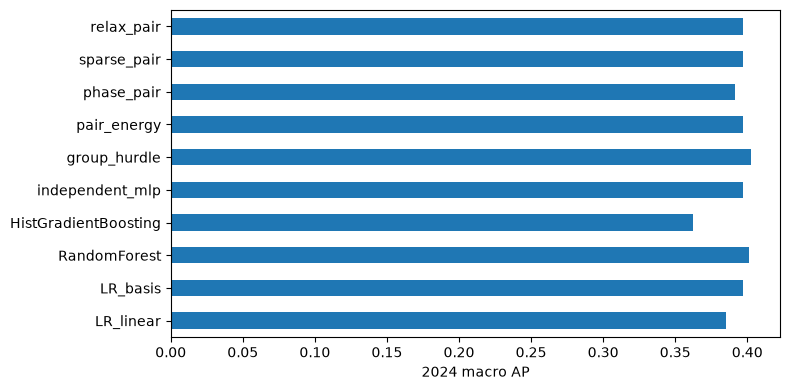

In [3]:
first=pd.DataFrame({k:v['mean'] for k,v in DATA['first_comparison']['models'].items()}).T
display(first[['macro_ap','macro_auc','macro_brier']])
first['macro_ap'].plot.barh(figsize=(8,4));plt.xlabel('2024 macro AP');plt.tight_layout();plt.show()

## 2. 실패 원인 점검

세 후보에서 LR 초기값이 학습 중 크게 이동하고 검증 AP가 낮아졌다. 이는 최적화 문제의 근거지만 원인이 하나뿐이라는 증명은 아니다.

,epoch,validation_macro_ap,anchor_weight_relative_change,model
0,0,0.397013,0.000000,phase_pair
1,1,0.396648,0.016122,phase_pair
2,5,0.392149,0.069010,phase_pair
3,10,0.392171,0.131839,phase_pair
4,20,0.390941,0.246947,phase_pair
5,40,0.385770,0.426353,phase_pair


,epoch,validation_macro_ap,anchor_weight_relative_change,model
0,0,0.397013,0.000000,sparse_pair
1,1,0.398271,0.016122,sparse_pair
2,5,0.393514,0.068530,sparse_pair
3,10,0.386732,0.130729,sparse_pair
4,20,0.389987,0.241458,sparse_pair
5,40,0.392918,0.429474,sparse_pair


,epoch,validation_macro_ap,anchor_weight_relative_change,model
0,0,0.397013,0.000000,relax_pair
1,1,0.397584,0.016122,relax_pair
2,5,0.393565,0.068666,relax_pair
3,10,0.387096,0.130887,relax_pair
4,20,0.388980,0.242192,relax_pair
5,40,0.391966,0.430483,relax_pair


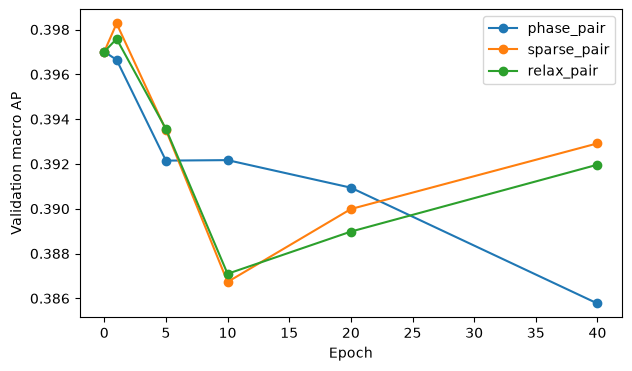

In [4]:
fig,ax=plt.subplots(figsize=(7,4))
for name,rows in DATA['training_diagnosis']['traces'].items():
    frame=pd.DataFrame(rows);display(frame.assign(model=name))
    ax.plot(frame.epoch,frame.validation_macro_ap,marker='o',label=name)
ax.set(xlabel='Epoch',ylabel='Validation macro AP');ax.legend();plt.show()

## 3. 같은 입력 누락 환경에서 수정 후보 비교

모든 모델에 동일한 정상+누락 학습자료를 제공했다. 기준선 고정·잔차 제한·그룹 간섭·라벨 간 이완을 적용했다. 인공 누락 테스트이며 자연 결측의 증거는 아니다.

,clean,missing20
LR_basis,0.400187,0.371379
RandomForest,0.409099,0.392506
HistGradientBoosting,0.391015,0.377651
group_hurdle,0.408044,0.377753
phase_reliable,0.401492,0.372026
sparse_reliable,0.402692,0.372720
relax_label,0.402461,0.372439


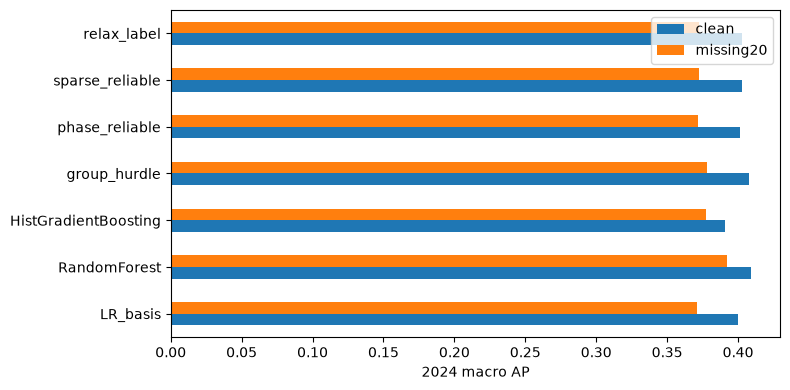

,clean,missing20
LR_basis,"[0.0, 0.0]","[0.0, 0.0]"
RandomForest,"[-0.020439972964821265, 0.033215327236866085]","[-0.008034222801000206, 0.04579571879272505]"
HistGradientBoosting,"[-0.03668743568274597, 0.025248092083032077]","[-0.011528805521084274, 0.02958583850366374]"
group_hurdle,"[0.00027174673541322414, 0.016917979664361354]","[-0.002050444962192996, 0.01341774858569805]"
phase_reliable,"[-0.00028930396208108887, 0.0029018197178658895]","[4.4583714888435385e-05, 0.0011742747130341045]"
sparse_reliable,"[0.000381375092045061, 0.005424854520097809]","[0.0003990396141371117, 0.0027773560985512205]"
relax_label,"[0.0005019444459425856, 0.004620020624094604]","[0.0003562288729168653, 0.0021125005522508625]"


In [5]:
second=pd.DataFrame({k:{e:v['macro_ap'] for e,v in m['mean'].items()} for k,m in DATA['adapted_comparison']['models'].items()}).T
display(second)
second.plot.barh(figsize=(8,4));plt.xlabel('2024 macro AP');plt.tight_layout();plt.show()
display(pd.DataFrame({k:{e:v['ci95'] for e,v in m.items()} for k,m in DATA['adapted_comparison']['paired'].items()}).T)

## 활용 결정

- 기존 NN: 유지.
- LR_basis: 단순 기준선.
- sparse_reliable: 사용자 아이디어 중 후속 후보. 작은 개선을 확인했지만 기존 NN/RF 우월성은 입증하지 못했다.
- RF: 누락 조건에서 높은 평가값, 큰 실행 비용.

2024 재사용·고정 모델 조건부 구간·다중 비교 보정 없음. 두 단계 사이의 구조/학습/보정 변경을 순수 구조 효과로 해석하지 않는다. 자세한 조건은COMPARISON.md에 있다.